In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle as pkl
import pickle 
import time
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import sklearn.metrics as sm
sns.set(style="whitegrid")
import matplotlib.gridspec as gridspec


from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from tqdm import tqdm
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold as skf, GridSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.base import clone 
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score
from sklearn.metrics import roc_auc_score, roc_curve

### Análise Exploratória dos Dados (EDA) e pré-processamento

In [16]:
file_path = "UDS.csv"

df = pd.read_csv(file_path, low_memory=False)

print("Dataset carregado com sucesso!")
print(f"Formato: {df.shape}")
print(f"Colunas: {list(df.columns)[:10]} ...")


Dataset carregado com sucesso!
Formato: (205908, 1024)
Colunas: ['NACCID', 'NACCADC', 'PACKET', 'FORMVER', 'VISITMO', 'VISITDAY', 'VISITYR', 'NACCVNUM', 'NACCAVST', 'NACCNVST'] ...


In [17]:

pd.set_option('display.max_columns', None)   
pd.set_option('display.width', 2000)         

print("Dimensões do dataset:", df.shape)
print("\nPrimeiras linhas:")
display(df.head(5))

print("\nLista de colunas do dataset:")
for col in df.columns:
    print(col)

chaves = [c for c in df.columns if c in [
    'NACCID','VISITMO','VISITYR','NACCVNUM','DEMENTED','NORMCOG','COGSTAT','NACCIDEM','MMSE','TRAILB','CDRSUM'
]]
print("\nColunas cognitivas e de diagnóstico encontradas:")
print(chaves)


Dimensões do dataset: (205908, 1024)

Primeiras linhas:


,NACCID,NACCADC,PACKET,FORMVER,VISITMO,VISITDAY,VISITYR,NACCVNUM,NACCAVST,NACCNVST,NACCDAYS,NACCFDYS,NACCCORE,NACCREAS,NACCREFR,BIRTHMO,BIRTHYR,SEX,HISPANIC,HISPOR,HISPORX,RACE,RACEX,RACESEC,RACESECX,RACETER,RACETERX,PRIMLANG,PRIMLANX,EDUC,MARISTAT,NACCLIVS,INDEPEND,RESIDENC,HANDED,INBIRMO,INBIRYR,INSEX,NEWINF,INHISP,INHISPOR,INHISPOX,NACCNINR,INRACE,INRACEX,INRASEC,INRASECX,INRATER,INRATERX,INEDUC,INRELTO,INRELTOX,INKNOWN,INLIVWTH,INVISITS,INCALLS,INRELY,NACCFAM,NACCMOM,NACCDAD,NACCAM,NACCAMX,NACCAMS,NACCAMSX,NACCFM,NACCFMX,NACCFMS,NACCFMSX,NACCOM,NACCOMX,NACCOMS,NACCOMSX,NACCFADM,NACCFFTD,ANYMEDS,DRUG1,DRUG2,DRUG3,DRUG4,DRUG5,DRUG6,DRUG7,DRUG8,DRUG9,DRUG10,DRUG11,DRUG12,DRUG13,DRUG14,DRUG15,DRUG16,DRUG17,DRUG18,DRUG19,DRUG20,DRUG21,DRUG22,DRUG23,DRUG24,DRUG25,DRUG26,DRUG27,DRUG28,DRUG29,DRUG30,DRUG31,DRUG32,DRUG33,DRUG34,DRUG35,DRUG36,DRUG37,DRUG38,DRUG39,DRUG40,TOBAC30,TOBAC100,SMOKYRS,PACKSPER,QUITSMOK,ALCOCCAS,ALCFREQ,CVHATT,HATTMULT,HATTYEAR,CVAFIB,CVANGIO,CVBYPASS,CVPACDEF,CVPACE,CVCHF,CVANGINA,CVHVALVE,CVOTHR,CVOTHRX,CBSTROKE,STROKMUL,NACCSTYR,CBTIA,TIAMULT,NACCTIYR,PD,PDYR,PDOTHR,PDOTHRYR,SEIZURES,NACCTBI,TBI,TBIBRIEF,TRAUMBRF,TBIEXTEN,TRAUMEXT,TBIWOLOS,TRAUMCHR,TBIYEAR,NCOTHR,NCOTHRX,DIABETES,DIABTYPE,HYPERTEN,HYPERCHO,B12DEF,THYROID,ARTHRIT,ARTHTYPE,ARTHTYPX,ARTHUPEX,ARTHLOEX,ARTHSPIN,ARTHUNK,INCONTU,INCONTF,APNEA,RBD,INSOMN,OTHSLEEP,OTHSLEEX,ALCOHOL,ABUSOTHR,ABUSX,PTSD,BIPOLAR,SCHIZ,DEP2YRS,DEPOTHR,ANXIETY,OCD,NPSYDEV,PSYCDIS,PSYCDISX,HEIGHT,WEIGHT,BPSYS,BPDIAS,HRATE,VISION,VISCORR,VISWCORR,HEARING,HEARAID,HEARWAID,ABRUPT,STEPWISE,SOMATIC,EMOT,HXHYPER,HXSTROKE,FOCLSYM,FOCLSIGN,HACHIN,CVDCOG,STROKCOG,CVDIMAG,CVDIMAG1,CVDIMAG2,CVDIMAG3,CVDIMAG4,CVDIMAGX,PDNORMAL,SPEECH,SPEECHX,FACEXP,FACEXPX,TRESTFAC,TRESTFAX,TRESTRHD,TRESTRHX,TRESTLHD,TRESTLHX,TRESTRFT,TRESTRFX,TRESTLFT,TRESTLFX,TRACTRHD,TRACTRHX,TRACTLHD,TRACTLHX,RIGDNECK,RIGDNEX,RIGDUPRT,RIGDUPRX,RIGDUPLF,RIGDUPLX,RIGDLORT,RIGDLORX,RIGDLOLF,RIGDLOLX,TAPSRT,TAPSRTX,TAPSLF,TAPSLFX,HANDMOVR,HANDMVRX,HANDMOVL,HANDMVLX,HANDALTR,HANDATRX,HANDALTL,HANDATLX,LEGRT,LEGRTX,LEGLF,LEGLFX,ARISING,ARISINGX,POSTURE,POSTUREX,GAIT,GAITX,POSSTAB,POSSTABX,BRADYKIN,BRADYKIX,MEMORY,ORIENT,JUDGMENT,COMMUN,HOMEHOBB,PERSCARE,CDRSUM,CDRGLOB,COMPORT,CDRLANG,NPIQINF,NPIQINFX,DEL,DELSEV,HALL,HALLSEV,AGIT,AGITSEV,DEPD,DEPDSEV,ANX,ANXSEV,ELAT,ELATSEV,APA,APASEV,DISN,DISNSEV,IRR,IRRSEV,MOT,MOTSEV,NITE,NITESEV,APP,APPSEV,NOGDS,SATIS,DROPACT,EMPTY,BORED,SPIRITS,AFRAID,HAPPY,HELPLESS,STAYHOME,MEMPROB,WONDRFUL,WRTHLESS,ENERGY,HOPELESS,BETTER,NACCGDS,BILLS,TAXES,SHOPPING,GAMES,STOVE,MEALPREP,EVENTS,PAYATTN,REMDATES,TRAVEL,NACCNREX,NORMEXAM,FOCLDEF,GAITDIS,EYEMOVE,PARKSIGN,RESTTRL,RESTTRR,SLOWINGL,SLOWINGR,RIGIDL,RIGIDR,BRADY,PARKGAIT,POSTINST,CVDSIGNS,CORTDEF,SIVDFIND,CVDMOTL,CVDMOTR,CORTVISL,CORTVISR,SOMATL,SOMATR,POSTCORT,PSPCBS,EYEPSP,DYSPSP,AXIALPSP,GAITPSP,APRAXSP,APRAXL,APRAXR,CORTSENL,CORTSENR,ATAXL,ATAXR,ALIENLML,ALIENLMR,DYSTONL,DYSTONR,MYOCLLT,MYOCLRT,ALSFIND,GAITNPH,OTHNEUR,OTHNEURX,B9CHG,DECSUB,DECIN,DECCLIN,DECCLCOG,COGMEM,COGORI,COGJUDG,COGLANG,COGVIS,COGATTN,COGFLUC,COGFLAGO,COGOTHR,COGOTHRX,NACCCOGF,NACCCGFX,COGMODE,COGMODEX,DECAGE,DECCLBE,BEAPATHY,BEDEP,BEVHALL,BEVWELL,BEVHAGO,BEAHALL,BEDEL,BEDISIN,BEIRRIT,BEAGIT,BEPERCH,BEREM,BEREMAGO,BEANX,BEOTHR,BEOTHRX,NACCBEHF,NACCBEFX,BEMODE,BEMODEX,BEAGE,DECCLMOT,MOGAIT,MOFALLS,MOTREM,MOSLOW,NACCMOTF,MOMODE,MOMODEX,MOMOPARK,PARKAGE,MOMOALS,ALSAGE,MOAGE,COURSE,FRSTCHG,LBDEVAL,FTLDEVAL,MMSECOMP,MMSELOC,MMSELAN,MMSELANX,MMSEVIS,MMSEHEAR,MMSEORDA,MMSEORLO,PENTAGON,NACCMMSE,NPSYCLOC,NPSYLAN,NPSYLANX,LOGIMO,LOGIDAY,LOGIYR,LOGIPREV,LOGIMEM,MEMUNITS,MEMTIME,UDSBENTC,UDSBENTD,UDSBENRS,DIGIF,DIGIFLEN,DIGIB,DIGIBLEN,ANIMALS,VEG,TRAILA,TRAILARR,TRAILALI,TRAILB,TRAILBRR,TRAILBLI,WAIS,BOSTON,UDSVERFC,UDSVERFN,UDSVERNF,UDSVERLC,UDSVERLR,UDSVERLN,UDSVERTN,UDSVERTE,UDSVERTI,COGSTAT,NACCC1,MOCACOMP,MOCAREAS,MOCALOC,MOCALAN,MOCALANX,MOCAVIS,MOCAHEAR,MOCATOTS,MOCATRAI,MOCACUBE,MOCACLOC,MOCACLON,MOCACLOH,MOCANAMI,MOCAREGI,MOCADIGI,MOCALETT,MOCASER7,MOCAREPE,MOCAFL


Lista de colunas do dataset:
NACCID
NACCADC
PACKET
FORMVER
VISITMO
VISITDAY
VISITYR
NACCVNUM
NACCAVST
NACCNVST
NACCDAYS
NACCFDYS
NACCCORE
NACCREAS
NACCREFR
BIRTHMO
BIRTHYR
SEX
HISPANIC
HISPOR
HISPORX
RACE
RACEX
RACESEC
RACESECX
RACETER
RACETERX
PRIMLANG
PRIMLANX
EDUC
MARISTAT
NACCLIVS
INDEPEND
RESIDENC
HANDED
INBIRMO
INBIRYR
INSEX
NEWINF
INHISP
INHISPOR
INHISPOX
NACCNINR
INRACE
INRACEX
INRASEC
INRASECX
INRATER
INRATERX
INEDUC
INRELTO
INRELTOX
INKNOWN
INLIVWTH
INVISITS
INCALLS
INRELY
NACCFAM
NACCMOM
NACCDAD
NACCAM
NACCAMX
NACCAMS
NACCAMSX
NACCFM
NACCFMX
NACCFMS
NACCFMSX
NACCOM
NACCOMX
NACCOMS
NACCOMSX
NACCFADM
NACCFFTD
ANYMEDS
DRUG1
DRUG2
DRUG3
DRUG4
DRUG5
DRUG6
DRUG7
DRUG8
DRUG9
DRUG10
DRUG11
DRUG12
DRUG13
DRUG14
DRUG15
DRUG16
DRUG17
DRUG18
DRUG19
DRUG20
DRUG21
DRUG22
DRUG23
DRUG24
DRUG25
DRUG26
DRUG27
DRUG28
DRUG29
DRUG30
DRUG31
DRUG32
DRUG33
DRUG34
DRUG35
DRUG36
DRUG37
DRUG38
DRUG39
DRUG40
TOBAC30
TOBAC100
SMOKYRS
PACKSPER
QUITSMOK
ALCOCCAS
ALCFREQ
CVHATT
HATTMULT
HATTYEAR
CVAFIB
CV

In [18]:
df['visit_date'] = pd.to_datetime(
    dict(year=df['VISITYR'], month=df['VISITMO'], day=df['VISITDAY']),
    errors='coerce'
)

ano_min = int(df['VISITYR'].min())
ano_max = int(df['VISITYR'].max())
print(f"O dataset cobre o período de {ano_min} até {ano_max}.")

print("\nDistribuição de registros por ano:")
print(df['VISITYR'].value_counts().sort_index())

baseline_por_ano = (
    df.sort_values(['NACCID','VISITYR','VISITMO'])
          .groupby('NACCID', as_index=False)
          .first()['VISITYR']
          .value_counts()
          .sort_index()
)
print("\nParticipantes cuja primeira visita foi em cada ano:")
print(baseline_por_ano)


O dataset cobre o período de 2005 até 2025.

Distribuição de registros por ano:
VISITYR
2005     1971
2006     9496
2007    10922
2008    11526
2009    11907
2010    11622
2011    10877
2012    11443
2013    11252
2014    10835
2015    10005
2016     9900
2017    10139
2018    10616
2019    11003
2020     8362
2021     8877
2022    10396
2023    11662
2024    11046
2025     2051
Name: count, dtype: int64

Participantes cuja primeira visita foi em cada ano:
VISITYR
2005    1971
2006    8458
2007    4918
2008    3397
2009    2776
2010    2475
2011    2185
2012    2425
2013    2090
2014    1812
2015    1660
2016    1914
2017    2505
2018    2479
2019    2460
2020     956
2021    1582
2022    2712
2023    3252
2024    2626
2025     351
Name: count, dtype: int64


In [ ]:

df['visit_date'] = pd.to_datetime(
    dict(year=df['VISITYR'], month=df['VISITMO'], day=df['VISITDAY']),
    errors='coerce'
)

inicio = pd.Timestamp('2005-09-01')
fim = pd.Timestamp('2015-02-28')

df_periodo = df[(df['visit_date'] >= inicio) & (df['visit_date'] <= fim)].copy()

print(f"linhas após filtro: {df_periodo.shape[0]:,}")
print(f"Participantes únicos: {df_periodo['NACCID'].nunique():,}")
print(f"Intervalo de datas: {df_periodo['visit_date'].min().date()} → {df_periodo['visit_date'].max().date()}")

print("\nDistribuição de visitas por ano:")
print(df_periodo['VISITYR'].value_counts().sort_index())


linhas após filtro: 103,423
Participantes únicos: 32,828
Intervalo de datas: 2005-09-01 → 2015-02-27

Distribuição de visitas por ano:
VISITYR
2005     1958
2006     9496
2007    10922
2008    11526
2009    11907
2010    11622
2011    10877
2012    11443
2013    11252
2014    10835
2015     1585
Name: count, dtype: int64


In [ ]:

df_clean = df_periodo.copy()

missing_codes = [8, 88, 888, 8888, 9, 99, 999, 9999, -4, -88, -99]

df_clean = df_clean.replace(missing_codes, np.nan)


if 'PACKET' in df_clean.columns:
    before = df_clean.shape[0]
    df_clean = df_clean[df_clean['PACKET'].astype(str).str.upper() != 'T']
    print(f"Visitas telefônicas removidas: {before - df_clean.shape[0]}")

df_clean['visit_date'] = pd.to_datetime(
    dict(year=df_clean['VISITYR'], month=df_clean['VISITMO'], day=df_clean.get('VISITDAY', 1)),
    errors='coerce'
)

before = df_clean.shape[0]
df_clean = df_clean[df_clean['visit_date'].notna()]
print(f"Registros sem data removidos: {before - df_clean.shape[0]}")

baseline_dates = (
    df_clean[df_clean['NACCVNUM'] == 1][['NACCID', 'visit_date']]
    .rename(columns={'visit_date': 'baseline_date'})
)
df_clean = df_clean.merge(baseline_dates, on='NACCID', how='left')
df_clean['months_from_baseline'] = (
    (df_clean['visit_date'] - df_clean['baseline_date']).dt.days / 30.44
)

print("\nResumo após limpeza:")
print(f"Linhas finais: {df_clean.shape[0]:,}")
print(f"Participantes únicos: {df_clean['NACCID'].nunique():,}")
print(f"Período: {df_clean['visit_date'].min().date()} → {df_clean['visit_date'].max().date()}")
print(f"Faixa de meses desde baseline: {df_clean['months_from_baseline'].min():.1f} → {df_clean['months_from_baseline'].max():.1f}")


Visitas telefônicas removidas: 5191
Registros sem data removidos: 22314

Resumo após limpeza:
Linhas finais: 75,918
Participantes únicos: 29,389
Período: 2005-10-01 → 2015-02-27
Faixa de meses desde baseline: 0.0 → 112.7


In [21]:
tabela_nacc = (
        df["DEMENTED"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência")
    )
tabela_nacc["%"] = (tabela_nacc["Frequência"] / tabela_nacc["Frequência"].sum() * 100).round(2)

print("\nDistribuição da variável DEMENTED:")
display(tabela_nacc)



Distribuição da variável DEMENTED:


,Código Diagnóstico,Frequência,%
0,0,146336,71.07
1,1,59572,28.93


In [22]:

tabela_nacc = (
        df["NACCUDSD"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência")
    )
tabela_nacc["%"] = (tabela_nacc["Frequência"] / tabela_nacc["Frequência"].sum() * 100).round(2)

print("\nDistribuição da variável NACCUDSD:")
display(tabela_nacc)


Distribuição da variável NACCUDSD:


,Código Diagnóstico,Frequência,%
0,1,100992,49.05
1,2,9090,4.41
2,3,36254,17.61
3,4,59572,28.93


In [23]:
##verificar esse codigo no de james
df_clean['months_from_baseline'] = df_clean['months_from_baseline'].astype(float)

baseline = df_clean[
    (df_clean['NACCVNUM'] == 1) &
    (df_clean['DEMENTED'] == 0) &
    (df_clean['FORMVER'] < 3) &                       
    (df_clean['PACKET'].astype(str).str.upper() != 'T')  
].copy()

followup = df_clean[
    (df_clean['NACCVNUM'] > 1) &
    (df_clean['DEMENTED'] == 1) &
    (df_clean['months_from_baseline'] <= 29)
][['NACCID', 'months_from_baseline', 'DEMENTED']]

incident_ids = followup['NACCID'].drop_duplicates()

df_final = baseline.copy()
df_final['incident_dementia'] = df_final['NACCID'].isin(incident_ids).astype(int)

total_participants = df_final['NACCID'].nunique()
n_dementia = df_final['incident_dementia'].sum()
perc_dementia = n_dementia / total_participants * 100

print(f"Total de participantes na baseline: {total_participants:,}")
print(f"Com demência incidente em ≤29 meses: {n_dementia:,} ({perc_dementia:.2f}%)")

followup_incident = followup[followup['NACCID'].isin(incident_ids)]
print("\nRange de meses até follow-up:")
print(followup_incident['months_from_baseline'].describe())




Total de participantes na baseline: 15,974
Com demência incidente em ≤29 meses: 939 (5.88%)

Range de meses até follow-up:
count    7259.000000
mean       17.448361
std         6.081098
min         1.675427
25%        12.187911
50%        14.421813
75%        24.063732
max        28.975033
Name: months_from_baseline, dtype: float64


In [24]:
base = df_final[['NACCID','VISITYR','incident_dementia']].drop_duplicates('NACCID')
tab = (base
       .groupby('VISITYR', as_index=False)
       .agg(n_baseline=('NACCID','nunique'),
            n_incident=('incident_dementia','sum')))
tab['perc_incident_%'] = 100*tab['n_incident']/tab['n_baseline']
tab.sort_values('VISITYR', inplace=True)
tab


,VISITYR,n_baseline,n_incident,perc_incident_%
0,2005,816,52,6.372549
1,2006,4124,255,6.183317
2,2007,2452,149,6.076672
3,2008,1647,114,6.921676
4,2009,1351,95,7.031828
5,2010,1103,81,7.343608
6,2011,1031,55,5.334627
7,2012,1246,87,6.982343
8,2013,1040,46,4.423077
9,2014,937,5,0.533618


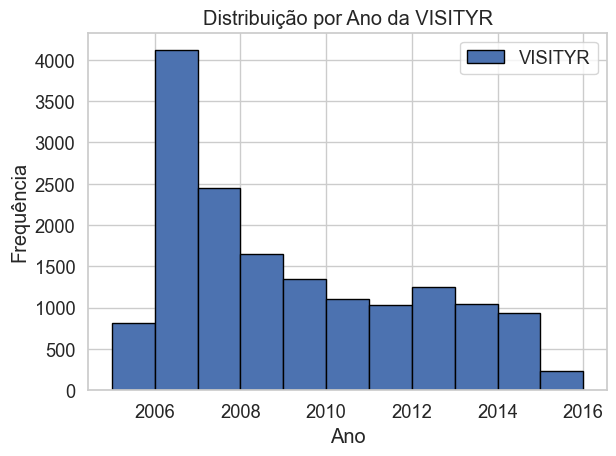

In [57]:
ax = df_final['VISITYR'].plot.hist(
    bins=range(2005, 2017),
    edgecolor='black',
    label='VISITYR'
)

ax.set_title("Distribuição por Ano da VISITYR")
ax.set_xlabel("Ano")
ax.set_ylabel("Frequência")
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:

df_no = df_final[df_final["incident_dementia"] == 0]
df_inc = df_final[df_final["incident_dementia"] == 1]

n_no = df_no.shape[0]
n_inc = df_inc.shape[0]

print("\n========== PARTICIPANT COUNTS ==========")
print(f"No incident dementia:  {n_no}")
print(f"Incident dementia:     {n_inc}")


def mean_sd_raw(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return s.mean(), s.std()

def count_pct_raw(series, value):
    s = series.dropna()
    c = np.sum(s == value)
    return c, (c/len(s))*100

def median_iqr_raw(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return (
        np.median(s),
        np.percentile(s,25),
        np.percentile(s,75)
    )


print("\n========== AGE ==========")
print("No dementia:", mean_sd_raw(df_no["NACCAGE"]))
print("Incident dementia:", mean_sd_raw(df_inc["NACCAGE"]))

print("\n========== SEX ==========")
print("Men (no dementia):", count_pct_raw(df_no["SEX"], 1))
print("Women (no dementia):", count_pct_raw(df_no["SEX"], 2))
print("Men (incident dementia):", count_pct_raw(df_inc["SEX"], 1))
print("Women (incident dementia):", count_pct_raw(df_inc["SEX"], 2))

print("\n========== LANGUAGE (PRIMLANG) ==========")
print("English speaker (no dementia):", count_pct_raw(df_no["PRIMLANG"], 1))
print("English speaker (incident dementia):", count_pct_raw(df_inc["PRIMLANG"], 1))

print("\n========== EDUCATION ==========")
print("No dementia:", mean_sd_raw(df_no["EDUC"]))
print("Incident dementia:", mean_sd_raw(df_inc["EDUC"]))

print("\n========== DEPENDENT LIVING (INDEPEND=2) ==========")
print("No dementia:", count_pct_raw(df_no["INDEPEND"], 2))
print("Incident dementia:", count_pct_raw(df_inc["INDEPEND"], 2))

print("\n========== CDR SUM ==========")
print("No dementia:", median_iqr_raw(df_no["CDRSUM"]))
print("Incident dementia:", median_iqr_raw(df_inc["CDRSUM"]))

print("\n========== MMSE ==========")
print("No dementia:", mean_sd_raw(df_no["NACCMMSE"]))
print("Incident dementia:", mean_sd_raw(df_inc["NACCMMSE"]))


def mean_sd(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return f"{s.mean():.1f} ({s.std():.1f})"

def count_pct(series, value):
    s = series.dropna()
    c = np.sum(s == value)
    return f"{c} ({(c/len(s))*100:.0f})"

def median_iqr(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return f"{np.median(s):.1f} ({np.percentile(s,25):.1f}-{np.percentile(s,75):.1f})"

table1 = {
    "Characteristic": [
        "Age, mean (SD)",
        "Sex: Men",
        "Sex: Women",
        "Native English speaker",
        "Education, mean (SD), years",
        "Dependent living",
        "CDR sum, median (IQR)",
        "Total MMSE score, mean (SD)"
    ],

    "No incident dementia": [
        mean_sd(df_no["NACCAGE"]),
        count_pct(df_no["SEX"], 1),
        count_pct(df_no["SEX"], 2),
        count_pct(df_no["PRIMLANG"], 1),
        mean_sd(df_no["EDUC"]),
        count_pct(df_no["INDEPEND"], 2),
        median_iqr(df_no["CDRSUM"]),
        mean_sd(df_no["NACCMMSE"])
    ],

    "Incident dementia": [
        mean_sd(df_inc["NACCAGE"]),
        count_pct(df_inc["SEX"], 1),
        count_pct(df_inc["SEX"], 2),
        count_pct(df_inc["PRIMLANG"], 1),
        mean_sd(df_inc["EDUC"]),
        count_pct(df_inc["INDEPEND"], 2),
        median_iqr(df_inc["CDRSUM"]),
        mean_sd(df_inc["NACCMMSE"])
    ]
}

df_table1 = pd.DataFrame(table1)

print("\n============================")
print(" Tabela 1 — Sample Characteristics")
print("============================\n")
display(df_table1)

df_table1.to_csv("5fold/Table1_Sample_Characteristics.csv", index=False)
print("\nArquivo salvo em: 5fold/Table1_Sample_Characteristics.csv")



========== PARTICIPANT COUNTS ==========
No incident dementia:  15035
Incident dementia:     939

========== AGE ==========
No dementia: (np.float64(71.36945117029863), np.float64(10.4418803407988))
Incident dementia: (np.float64(74.9665587918015), np.float64(9.245742895377015))

========== SEX ==========
Men (no dementia): (np.int64(6031), np.float64(40.11306950448952))
Women (no dementia): (np.int64(9004), np.float64(59.88693049551047))
Men (incident dementia): (np.int64(502), np.float64(53.46112886048988))
Women (incident dementia): (np.int64(437), np.float64(46.53887113951012))

========== LANGUAGE (PRIMLANG) ==========
English speaker (no dementia): (np.int64(13895), np.float64(93.94226218646475))
English speaker (incident dementia): (np.int64(882), np.float64(95.45454545454545))

========== EDUCATION ==========
No dementia: (np.float64(15.448505887958614), np.float64(3.200746538006559))
Incident dementia: (np.float64(15.395604395604396), np.float64(3.127222187693382))

=========

,Characteristic,No incident dementia,Incident dementia
0,"Age, mean (SD)",71.4 (10.4),75.0 (9.2)
1,Sex: Men,6031 (40),502 (53)
2,Sex: Women,9004 (60),437 (47)
3,Native English speaker,13895 (94),882 (95)
4,"Education, mean (SD), years",15.4 (3.2),15.4 (3.1)
5,Dependent living,1162 (8),332 (36)
6,"CDR sum, median (IQR)",0.0 (0.0-0.5),1.5 (1.0-2.5)
7,"Total MMSE score, mean (SD)",29.9 (10.7),27.6 (10.4)



Arquivo salvo em: 5fold/Table1_Sample_Characteristics.csv


In [ ]:
predictor_vars = [
    # --- TRAILB ---
    "NACCREAS","NACCREFR","BIRTH_#MOS","SEX","HISPANIC","HISPOR","PRIMLANG","EDUC","NACCLIVS","INDEPEND","RESIDENC","MARISTAT","HANDED","NACCAGE","NACCNIHR",
    "INBIR_#MOS","INSEX","INRELTO","INLIVWTH","INVISITS","INCALLS","INRELY","NACCMOM","NACCDAD","NACCFAM","ANYMEDS",
    # --- Medicamentos / Condições médicas ---
    "NACCAMD","NACCHTNC","NACCACEI","NACCAAAS","NACCBETA","NACCCCBS","NACCDIUR","NACCVASD","NACCANGI","NACCAHTN",
    "NACCLIPL","NACCNSD","NACCAC","NACCADEP","NACCAPSY","NACCAANX","NACCPDMD","NACCEMD","NACCEPMD","NACCDBMD",
    # --- Exames clínicos e vitais ---
    "BPSYS","BPDIAS","HRATE","VISION","VISCORR","VISWCORR","HEARING","HEARAID","HEARWAID","NACCBMI","ABRUPT","STEPWISE","SOMATIC","EMOT",
    # --- Doenças cardiovasculares e neurológicas ---
    "CVHATT","CVAFIB","CVANGIO","CVBYPASS","CVPACE","CVCHF","CVOTHR","CBSTROKE","NACCSTYR_#YRS","CBTIA","NACCTIYR_#YRS",
    "PD","PDYR_#YRS","PDOTHR","PDOTHRYR_#YRS","SEIZURES","TRAUMBRF","TRAUMEXT","TRAUMCHR","NCOTHR","HYPERTEN","HYPERCHO","DIABETES","B12DEF","THYROID",
    "INCONTU","INCONTF","DEP2YRS","DEPOTHR","ALCOHOL","TOBAC30","TOBAC100","SMOKYRS","PACKSPER","QUITSMOK","ABUSOTHR","PSYCDIS","NACCTBI",
    # --- Neurológico / Motricidade / Parkinsonismo ---
    "GAIT","POSSTAB","BRADYKIN","PDNORMAL","FOCLSYM","FOCLSIGN","HACHIN","HXHYPER","HXSTROKE","SPEECH","FACEXP",
    "TRESTFAC","TRESTLHD","TRESTLFT","TRESTFHD","TRESTRHD","TRESTRFT","RIGDNECK","RIGDUPRT","RIGDUPLF","RIGDLORT",
    "RIGDLOLF","TAPSRT","TAPSLF","HANDMOVR","HANDMOVL","HANDALTR","HANDALTL","LEGRT","LEGLF","ARISING","POSTURE",
    # --- Avaliação cognitiva / CDR ---
    "MEMORY","ORIENT","JUDGMENT","COMMUN","HOMEHOBB","PERSCARE","CDRSUM","CDRGLOB","COGSTAT","NACCC1",
    # --- Testes neuropsicológicos ---
    "MMSELOC","MMSELAN","MMSEORDA","MMSEORDA_PROB","MMSEORLO","MMSEORLO_PROB","NACCMMSE","NACCMMSE_PROB",
    "NPSYCLOC","NPSYLAN","LOGIMEM","LOGIMEM_PROB","DIGIF","DIGIF_PROB","DIGIFLEN","DIGIFLEN_PROB","DIGIB","DIGIB_PROB",
    "DIGIBLEN","DIGIBLEN_PROB","ANIMALS","ANIMALS_PROB","VEG","VEG_PROB","TRAILA","TRAILA_PROB","TRAILB","TRAILB_PROB",
    "WAIS","WAIS_PROB","MEMUNITS","MEMUNITS_PROB","MEMTIME","BOSTON","BOSTON_PROB",
    # --- Depressão e comportamento ---
    "NACCGDS","NACCBEHF","NACCBEFX","BEAPATHY","BEDEP","BEVHALL","BEAHALL","BEDEL","BEDISIN","BEIRRIT","BEAGIT","BEPERCH","BEOTHR",
    "SATIS","DROPACT","EMPTY","BORED","SPIRITS","AFRAID","HAPPY","HELPLESS","STAYHOME","MEMPROB","WONDRFUL","WRTHLESS","ENERGY","HOPELESS","BETTER",
    # --- Funcionalidade diária ---
    "BILLS","TAXES","SHOPPING","GAMES","STOVE","MEALPREP","EVENTS","PAYATTN","REMDATES","TRAVEL","FOCLDEF","GAITDIS","EYEMOVE",
    # --- Movimento e modo ---
    "MOGAIT","MOFALLS","MOTREM","MOSLOW","NACCMOTF","MOMODE","COURSE","FRSTCHG","DECIN","DECSUB","DECAGE","COGMEM","COGJUDG","COGLANG","COGVIS","COGATTN","COGOTHR","COGMODE",
    # --- Variáveis aleatórias auxiliares ---
    "RANDVAR_0","RANDVAR_1","RANDVAR_2","RANDVAR_3"
]

cols_present = [col for col in predictor_vars if col in df_final.columns]
cols_missing = [col for col in predictor_vars if col not in df_final.columns]

print(f"Total de variáveis esperadas: {len(predictor_vars)}")
print(f"Encontradas no dataset: {len(cols_present)}")
print(f"Ausentes: {len(cols_missing)}")

print("\nExemplo de variáveis ausentes:")
print(cols_missing[:30])

X = df_final[cols_present].copy()
y = df_final['incident_dementia']

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")


Total de variáveis esperadas: 238
Encontradas no dataset: 212
Ausentes: 26

Exemplo de variáveis ausentes:
['BIRTH_#MOS', 'INBIR_#MOS', 'NACCSTYR_#YRS', 'NACCTIYR_#YRS', 'PDYR_#YRS', 'PDOTHRYR_#YRS', 'TRESTFHD', 'MMSEORDA_PROB', 'MMSEORLO_PROB', 'NACCMMSE_PROB', 'LOGIMEM_PROB', 'DIGIF_PROB', 'DIGIFLEN_PROB', 'DIGIB_PROB', 'DIGIBLEN_PROB', 'ANIMALS_PROB', 'VEG_PROB', 'TRAILA_PROB', 'TRAILB_PROB', 'WAIS_PROB', 'MEMUNITS_PROB', 'BOSTON_PROB', 'RANDVAR_0', 'RANDVAR_1', 'RANDVAR_2', 'RANDVAR_3']

Shape de X: (15974, 212)
Shape de y: (15974,)


In [28]:
name_map = {
    'BIRTH_#MOS': 'BIRTHMO',
    'INBIR_#MOS': 'INBIRMO',
    'NACCSTYR_#YRS': 'NACCSTYR',
    'NACCTIYR_#YRS': 'NACCTIYR',
    'PDYR_#YRS': 'PDYR',
    'PDOTHRYR_#YRS': 'PDOTHRYR',
    'TRESTFHD': 'TRESTRHD'
}

predictor_vars_fixed = [
    name_map.get(var, var) for var in predictor_vars
    if not var.endswith('_PROB') and not var.startswith('RANDVAR_')
]

cols_present_fixed = [c for c in predictor_vars_fixed if c in df_final.columns]
cols_missing_fixed = [c for c in predictor_vars_fixed if c not in df_final.columns]

print(f"Total após ajuste: {len(predictor_vars_fixed)}")
print(f"Encontradas no dataset: {len(cols_present_fixed)}")
print(f"Ausentes após ajuste: {len(cols_missing_fixed)}")
print("\nVariáveis ainda ausentes (se houver):")
print(cols_missing_fixed)

X = df_final[cols_present_fixed].copy()
y = df_final['incident_dementia']

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")


Total após ajuste: 219
Encontradas no dataset: 219
Ausentes após ajuste: 0

Variáveis ainda ausentes (se houver):
[]

Shape de X: (15974, 219)
Shape de y: (15974,)


In [29]:
def impute(raw_data):
    data = raw_data.copy()
    for var_ind in range(data.shape[1]):
        variable = data[:, var_ind]
        if np.sum(pd.isnull(variable)) > 0:
            sample = variable[~pd.isnull(variable)]
            if len(sample) > 0:
                replace_vals = np.random.choice(sample, np.sum(pd.isnull(variable)), replace=True)
                variable[pd.isnull(variable)] = replace_vals
                data[:, var_ind] = variable
    return data

print("\n Aplicando imputação de valores faltantes (estilo James)...")
X = X.apply(pd.to_numeric, errors='coerce')  
X_array = X.values.astype(float)             
X_imputed = impute(X_array)
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

X_model = X_imputed_df  

print(f"Imputação concluída — Shape: {X_model.shape} | NaN restantes: {np.isnan(X_model).sum().sum()}")



 Aplicando imputação de valores faltantes (estilo James)...
Imputação concluída — Shape: (15974, 219) | NaN restantes: 0


In [ ]:
X_imputed = X_imputed_df

assert 'X_imputed' in globals() and isinstance(X_imputed, pd.DataFrame), "⚠️ Defina X_imputed antes (dataset imputado)."

def infer_type(s: pd.Series) -> str:
    """Classifica variável como Binary, Continuous ou Categorical (estilo James)."""
    s2 = s.dropna()
    nunique = s2.nunique(dropna=True)
    if nunique == 2:
        return 'Binary'
    if pd.api.types.is_numeric_dtype(s):
        return 'Continuous' if nunique > 10 else 'Categorical'
    if pd.api.types.is_string_dtype(s) or str(s.dtype) in ('object', 'category'):
        return 'Categorical'
    return 'Unknown'

cols = list(X_imputed.columns)
var_types = []

for c in cols:
    try:
        s = pd.Series(X_imputed[c].astype(float), dtype=float)  
        tipo = infer_type(s)
    except Exception:
        tipo = 'Unknown'
    var_types.append(tipo)


var_types_df = pd.DataFrame({'VAR_NAME': cols, 'VAR_TYPE': var_types})
print("  Tipagem inferida (amostra):")
display(var_types_df.head(15))

print("\n  Contagem de tipos:")
print(var_types_df['VAR_TYPE'].value_counts())

variables_for_dummy = var_types_df['VAR_NAME'].values
var_types_for_dummy = var_types_df['VAR_TYPE'].values

with open('ImpVars_dummy.pkl', 'wb') as f:
    pickle.dump([None, None, None, variables_for_dummy, None, var_types_for_dummy, None], f)

print(f"\n  'ImpVars_dummy.pkl' salvo. Total de variáveis: {len(variables_for_dummy)}")

  Tipagem inferida (amostra):


,VAR_NAME,VAR_TYPE
0,NACCREAS,Categorical
1,NACCREFR,Binary
2,BIRTHMO,Categorical
3,SEX,Binary
4,HISPANIC,Binary
5,HISPOR,Categorical
6,PRIMLANG,Categorical
7,EDUC,Continuous
8,NACCLIVS,Categorical
9,INDEPEND,Categorical



  Contagem de tipos:
VAR_TYPE
Categorical    95
Binary         92
Continuous     30
Unknown         2
Name: count, dtype: int64

  'ImpVars_dummy.pkl' salvo. Total de variáveis: 219


In [ ]:
X_values_imputed = X_model.values
columns_imputed = X_model.columns.values
outcome_values = y.values

with open('processed_data.pkl', 'wb') as f:
    pickle.dump([X_values_imputed, columns_imputed, outcome_values], f)
print(" Arquivo 'processed_data.pkl' salvo com sucesso.")

participant_ids = df_final['NACCID'].astype(str).values
np.save('NACCID.npy', participant_ids)
print(" Arquivo 'NACCID.npy' salvo com sucesso.")

print(f"Shape dos dados (X) salvos: {X_values_imputed.shape}")
print(f"Número de colunas salvas: {len(columns_imputed)}")
print(f"Shape do outcome (y) salvo: {outcome_values.shape}")
print(f"Número de IDs salvos: {len(participant_ids)}")

 Arquivo 'processed_data.pkl' salvo com sucesso.
 Arquivo 'NACCID.npy' salvo com sucesso.
Shape dos dados (X) salvos: (15974, 219)
Número de colunas salvas: 219
Shape do outcome (y) salvo: (15974,)
Número de IDs salvos: 15974


### Modelagem e Avaliação

In [32]:
def calculate_diagnostic_performance(actual_predicted):
    #actual_predicted = test_results.values
    actual_positives = actual_predicted[:, 0] == 1
    actual_negatives = actual_predicted[:, 0] == 0
    test_positives = actual_predicted[:, 1] == 1
    test_negatives = actual_predicted[:, 1] == 0
    test_correct = actual_predicted[:, 0] == actual_predicted[:, 1]
    accuracy = np.average(test_correct)
    true_positives = actual_positives & test_positives
    true_negatives = actual_negatives & test_negatives
    sensitivity = np.sum(true_positives) / np.sum(actual_positives)
    specificity = np.sum(true_negatives) / np.sum(actual_negatives)
    positive_likelihood = sensitivity / (1 - specificity)
    negative_likelihood = (1 - sensitivity) / specificity
    false_postive_rate = 1 - specificity
    false_negative_rate = 1 - sensitivity
    positive_predictive_value = np.sum(true_positives) / np.sum(test_positives)
    negative_predicitive_value = np.sum(true_negatives) / np.sum(test_negatives)
    positive_rate = np.mean(actual_predicted[:,1])
    return ['accuracy', 'sensitivity', 'specificity', 'positive_likelihood',
            'negative_likelihood', 'false_postive_rate', 'false_negative_rate',
            'positive_predictive_value', 'negative_predicitive_value',
            'positive_rate'], [accuracy, sensitivity, specificity, positive_likelihood,
            negative_likelihood, false_postive_rate, false_negative_rate,
            positive_predictive_value, negative_predicitive_value,
            positive_rate]

In [33]:
def bootstrap_metrics(y_true, y_pred, y_prob, n_iter):
    
    vals=[]
    for iteration in range(n_iter):
        selection = np.random.randint(0,len(y_true), size=3460)

        true = [y_true[i] for i in selection]
        pred = [y_pred[i] for i in selection]
        prob = [y_prob[i] for i in selection]
        
        ap = np.array(list(zip(true,pred)))
        _,performance = calculate_diagnostic_performance(ap)
        
        auc = roc_auc_score(true, prob)
        
        
        vals.append([performance[0],performance[1], performance[2], performance[-2], performance[-3], auc])
        
    return vals

In [ ]:

with open('processed_data.pkl', 'rb') as f:
    data, variables, outcome = pickle.load(f)

print("'processed_data.pkl' carregado com sucesso.")
print(f"Shape inicial dos dados: {data.shape}")

enc = preprocessing.OneHotEncoder()
count = 0

for i, tipo in enumerate(var_types):
    if tipo == 'Categorical':
        print(f"Codificando: {variables[i - count]}")
        
        X = data[:, i - count].reshape(-1, 1)
        enc.fit(X)
        X_new = enc.transform(X).toarray()
        
        data = np.delete(data, i - count, axis=1)
        data = np.hstack((data, X_new))
        
        n_novas = [f"{variables[i - count]}_{cat}" for cat in enc.categories_[0]]
        variables = np.delete(variables, i - count)
        variables = np.concatenate((variables, n_novas))
        
        count += 1

print(f"One-Hot Encoding concluído. Novo shape: {data.shape}")

data = preprocessing.scale(data.astype(float))
print("Escalonamento aplicado (preprocessing.scale — média=0, desvio=1).")

np.save('encoded_data.npy', data)
np.save('outcome.npy', np.array(outcome, dtype=int))
np.save('encoded_variables.npy', np.array(variables))

print("\nArquivos salvos com sucesso:")
print(" - encoded_data.npy")
print(" - outcome.npy")
print(" - encoded_variables.npy")
print(f"Shape final: {data.shape} | Variáveis: {len(variables)}")


'processed_data.pkl' carregado com sucesso.
Shape inicial dos dados: (15974, 219)
Codificando: NACCREAS
Codificando: BIRTHMO
Codificando: HISPOR
Codificando: PRIMLANG
Codificando: NACCLIVS
Codificando: INDEPEND
Codificando: RESIDENC
Codificando: MARISTAT
Codificando: HANDED
Codificando: NACCNIHR
Codificando: INBIRMO
Codificando: INRELTO
Codificando: INVISITS
Codificando: INCALLS
Codificando: CVHATT
Codificando: CVAFIB
Codificando: CVANGIO
Codificando: CVBYPASS
Codificando: CVPACE
Codificando: CVCHF
Codificando: CVOTHR
Codificando: CBSTROKE
Codificando: CBTIA
Codificando: SEIZURES
Codificando: TRAUMBRF
Codificando: TRAUMEXT
Codificando: TRAUMCHR
Codificando: NCOTHR
Codificando: HYPERTEN
Codificando: HYPERCHO
Codificando: DIABETES
Codificando: B12DEF
Codificando: THYROID
Codificando: INCONTU
Codificando: INCONTF
Codificando: ALCOHOL
Codificando: PACKSPER
Codificando: ABUSOTHR
Codificando: PSYCDIS
Codificando: GAIT
Codificando: POSSTAB
Codificando: BRADYKIN
Codificando: HACHIN
Codificando

In [ ]:
def run_k_fold(model, name, params, data, outcome, n_splits=5, n_bootstrap_iter=1000):
  
    sk = skf(n_splits=n_splits, shuffle=True, random_state=42)

    auc, metrics, models, err, feat, probs, preds = [], [], [], [], [], [], []

    outcome = np.array(outcome, dtype=int)

    for train_idx, test_idx in sk.split(data, outcome):
        clf = GridSearchCV(model, params, n_jobs=-1, scoring='roc_auc')
        clf.fit(data[train_idx], outcome[train_idx])

        best = clf.best_estimator_
        models.append(best)

        pred = best.predict(data[test_idx])
        prob = best.predict_proba(data[test_idx])[:, 1]

        auc.append(roc_auc_score(outcome[test_idx], prob))

        ap = np.column_stack((outcome[test_idx], pred))
        _, performance = calculate_diagnostic_performance(ap)
        metrics.append(performance)

        errors = bootstrap_metrics(outcome[test_idx], pred, prob, n_iter=n_bootstrap_iter)
        err.append(errors)

        probs.extend(prob)
        preds.extend(pred)

        print(f"{name} Fold concluído — AUC: {auc[-1]:.3f}")

        if name in ['RF', 'GB']:
            feat.append(best.feature_importances_)

        elif hasattr(best, 'coef_'):
             feat.append(best.coef_[0])
    


        elif name in ["MLP","BNB"]:
            r = permutation_importance(
                best, data[test_idx], outcome[test_idx],
                n_repeats=3, random_state=42, scoring='roc_auc'
            )
            feat.append(r.importances_mean)



        else:
            feat.append(np.zeros(data.shape[1]))

    return auc, metrics, models, err, feat, probs, preds


### Random forest

In [ ]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 10, 20],
    'max_depth': [10, 50],
    'max_features': [20, 50]
}

X_final = np.load('encoded_data.npy')
y_final = np.load('outcome.npy')
final_variable_names = np.load('encoded_variables.npy', allow_pickle=True)
print(f" Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")

model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced_subsample')

print("\nIniciando avaliação Random Forest (5-Fold + Bootstrap 1000)...")
rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds = run_k_fold(
    model, 'RF', rf_params, X_final, y_final
)

rf_mean = np.mean(rf_metrics, axis=0)
print("\n MÉDIAS — Random Forest (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {rf_mean[0]:.3f}")
print(f"  Sensitivity:  {rf_mean[1]:.3f}")
print(f"  Specificity:  {rf_mean[2]:.3f}")
print(f"  PPV:          {rf_mean[7]:.3f}")
print(f"  NPV:          {rf_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(rf_auc):.3f}")

os.makedirs('5fold', exist_ok=True)
with open('5fold/rf_results.pkl', 'wb') as f:
    pickle.dump(
        [rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds, final_variable_names],
        f
    )

print("\nResultados salvos com sucesso em: '5fold/rf_results.pkl'")
print(" Execução Random Forest concluída.")


 Dados finais carregados: 15974 amostras × 554 variáveis.

Iniciando avaliação Random Forest (5-Fold + Bootstrap 1000)...
RF Fold concluído — AUC: 0.908
RF Fold concluído — AUC: 0.879
RF Fold concluído — AUC: 0.895
RF Fold concluído — AUC: 0.886
RF Fold concluído — AUC: 0.890

 MÉDIAS — Random Forest (5-Fold + Bootstrap 1000):
  Accuracy:     0.936
  Sensitivity:  0.128
  Specificity:  0.987
  PPV:          0.419
  NPV:          0.948
  AUC (média):  0.892

Resultados salvos com sucesso em: '5fold/rf_results.pkl'
 Execução Random Forest concluída.


In [ ]:

with open('5fold/rf_results.pkl', 'rb') as f:
    rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds, final_variable_names = pickle.load(f)

import numpy as np
gb_mean = np.mean(rf_metrics, axis=0)

with open('5fold/rf_results.pkl', 'wb') as f:
    pickle.dump(
        [rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds, final_variable_names,rf_mean],
        f
    )

print("\nMédias atualizadas salvas em: '5fold/rf_results.pkl'")


Médias atualizadas salvas em: '5fold/rf_results.pkl'


### Logistic regression

In [36]:
lr_params = {
    'C': [0.1, 1, 5, 10],
    'max_iter': [10000]
}

X_final = np.load('encoded_data.npy')
y_final = np.load('outcome.npy')
final_variable_names = np.load('encoded_variables.npy', allow_pickle=True)
print(f" Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")

model = LogisticRegression(random_state=42, class_weight='balanced')

print("\nIniciando avaliação Logistic Regression (5-Fold + Bootstrap 1000)...")
lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds = run_k_fold(
    model, 'LR', lr_params, X_final, y_final
)

lr_mean = np.mean(lr_metrics, axis=0)
print("\n MÉDIAS — Logistic Regression (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {lr_mean[0]:.3f}")
print(f"  Sensitivity:  {lr_mean[1]:.3f}")
print(f"  Specificity:  {lr_mean[2]:.3f}")
print(f"  PPV:          {lr_mean[7]:.3f}")
print(f"  NPV:          {lr_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(lr_auc):.3f}")

print("\n--- Calculando Precisão Agregada (LR) ---")
y_true_lr_agg = np.array(y_final)
y_pred_lr_agg = np.array(lr_preds)
precision_lr_agg = precision_score(y_true_lr_agg[:len(y_pred_lr_agg)], y_pred_lr_agg, zero_division=0)
print(f"  Precisão Agregada (5 Folds): {precision_lr_agg:.4f}")

os.makedirs('5fold', exist_ok=True)
with open('5fold/lr_results.pkl', 'wb') as f:
    pickle.dump(
        [lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds, final_variable_names],
        f
    )

print("\n Resultados salvos com sucesso em: '5fold/lr_results.pkl'")
print(" Execução Logistic Regression concluída.")


 Dados finais carregados: 15974 amostras × 554 variáveis.

Iniciando avaliação Logistic Regression (5-Fold + Bootstrap 1000)...
LR Fold concluído — AUC: 0.855
LR Fold concluído — AUC: 0.832
LR Fold concluído — AUC: 0.843
LR Fold concluído — AUC: 0.853
LR Fold concluído — AUC: 0.851

 MÉDIAS — Logistic Regression (5-Fold + Bootstrap 1000):
  Accuracy:     0.825
  Sensitivity:  0.700
  Specificity:  0.833
  PPV:          0.207
  NPV:          0.978
  AUC (média):  0.847

--- Calculando Precisão Agregada (LR) ---
  Precisão Agregada (5 Folds): 0.0552

 Resultados salvos com sucesso em: '5fold/lr_results.pkl'
 Execução Logistic Regression concluída.


In [ ]:

with open('5fold/lr_results.pkl', 'rb') as f:
    lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds, final_variable_names = pickle.load(f)

import numpy as np
gb_mean = np.mean(lr_metrics, axis=0)

with open('5fold/lr_results.pkl', 'wb') as f:
    pickle.dump(
        [lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds, final_variable_names,lr_mean],
        f
    )

print("\nMédias atualizadas salvas em: '5fold/lr_results.pkl'")


Médias atualizadas salvas em: '5fold/lr_results.pkl'


### BNB

In [ ]:


bnb_params = {
    'alpha': [1.0],
    'class_prior': [None],   
}


X_final = np.load('encoded_data.npy')
y_final = np.load('outcome.npy')
final_variable_names = np.load('encoded_variables.npy', allow_pickle=True)

print(f" Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")


model = BernoulliNB()

print("\n Iniciando avaliação BernoulliNB (5-Fold + Bootstrap 1000)...")

bnb_auc, bnb_metrics, bnb_models, bnb_err, bnb_feat, bnb_probs, bnb_preds = run_k_fold(
    model, 'BNB', bnb_params, X_final, y_final
)

bnb_mean = np.mean(bnb_metrics, axis=0)

print("\n MÉDIAS — BernoulliNB:")
print(f"  Accuracy:     {bnb_mean[0]:.3f}")
print(f"  Sensitivity:  {bnb_mean[1]:.3f}")
print(f"  Specificity:  {bnb_mean[2]:.3f}")
print(f"  PPV:          {bnb_mean[7]:.3f}")
print(f"  NPV:          {bnb_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(bnb_auc):.3f}")

os.makedirs('5fold', exist_ok=True)
with open('5fold/bnb_results.pkl', 'wb') as f:
    pickle.dump(
        [bnb_auc, bnb_metrics, bnb_models, bnb_err, bnb_feat, bnb_probs, bnb_preds, final_variable_names],
        f
    )

print("\nResultados salvos em: '5fold/bnb_results.pkl'")
print(" Execução BernoulliNB concluída.")


 Dados finais carregados: 15974 amostras × 554 variáveis.

 Iniciando avaliação BernoulliNB (5-Fold + Bootstrap 1000)...
BNB Fold concluído — AUC: 0.873
BNB Fold concluído — AUC: 0.859
BNB Fold concluído — AUC: 0.868
BNB Fold concluído — AUC: 0.860
BNB Fold concluído — AUC: 0.861

 MÉDIAS — BernoulliNB:
  Accuracy:     0.800
  Sensitivity:  0.777
  Specificity:  0.802
  PPV:          0.197
  NPV:          0.983
  AUC (média):  0.864

Resultados salvos em: '5fold/bnb_results.pkl'
 Execução BernoulliNB concluída.


### MLP


In [ ]:

mlp_params = {
    'hidden_layer_sizes': [(256,), (512,), (1024,)], 
    'activation': ['relu'],                           
    'alpha': [0.0001, 0.001, 0.01],                  
    'learning_rate_init': [0.001],                 
    'batch_size': [16]                                
}


X_final = np.load('encoded_data.npy')
y_final = np.load('outcome.npy')
final_variable_names = np.load('encoded_variables.npy', allow_pickle=True)

print(f"Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")


model = MLPClassifier(
    solver='adam',
    max_iter=300,         
    random_state=42
)


print("\n Iniciando avaliação MLP (5-Fold + Bootstrap 1000)...")

mlp_auc, mlp_metrics, mlp_models, mlp_err, mlp_feat, mlp_probs, mlp_preds = run_k_fold(
    model, 'MLP', mlp_params, X_final, y_final
)


mlp_mean = np.mean(mlp_metrics, axis=0)

print("\n MÉDIAS — MLP (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {mlp_mean[0]:.3f}")
print(f"  Sensitivity:  {mlp_mean[1]:.3f}")
print(f"  Specificity:  {mlp_mean[2]:.3f}")
print(f"  PPV:          {mlp_mean[7]:.3f}")
print(f"  NPV:          {mlp_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(mlp_auc):.3f}")

os.makedirs('5fold', exist_ok=True)

with open('5fold/mlp_results.pkl', 'wb') as f:
    pickle.dump(
        [mlp_auc, mlp_metrics, mlp_models, mlp_err,
         mlp_feat, mlp_probs, mlp_preds, final_variable_names],
        f
    )

print("\n Resultados salvos com sucesso em: '5fold/mlp_results.pkl'")
print("✨ Execução MLP concluída.")


Dados finais carregados: 15974 amostras × 554 variáveis.

🧠 Iniciando avaliação MLP (5-Fold + Bootstrap 1000)...
MLP Fold concluído — AUC: 0.821
MLP Fold concluído — AUC: 0.817
MLP Fold concluído — AUC: 0.832
MLP Fold concluído — AUC: 0.831
MLP Fold concluído — AUC: 0.818

📊 MÉDIAS — MLP (5-Fold + Bootstrap 1000):
  Accuracy:     0.931
  Sensitivity:  0.162
  Specificity:  0.979
  PPV:          0.324
  NPV:          0.949
  AUC (média):  0.824

💾 Resultados salvos com sucesso em: '5fold/mlp_results.pkl'
✨ Execução MLP concluída.


In [ ]:
import pickle

with open('5fold/mlp_results.pkl', 'rb') as f:
    mlp_auc, mlp_metrics, mlp_models, mlp_err, mlp_feat, mlp_probs, mlp_preds, final_variable_names = pickle.load(f)

import numpy as np
gb_mean = np.mean(lr_metrics, axis=0)

with open('5fold/mlp_results.pkl', 'wb') as f:
    pickle.dump(
        [ mlp_auc, mlp_metrics, mlp_models, mlp_err, mlp_feat, mlp_probs, mlp_preds, final_variable_names ,mlp_mean],
        f
    )

print("\nMédias atualizadas salvas em: '5fold/mlp_results.pkl'")


Médias atualizadas salvas em: '5fold/mlp_results.pkl'


### Gradient boosting

In [ ]:
gb_params = {
    'n_estimators': [50, 100, 200],
    'criterion': ['friedman_mse', 'squared_error', 'absolute_error'],
    'min_samples_split': [2, 5, 10, 20],
    'max_depth': [5, 10, 50],
    'max_features': ['sqrt', 'log2', 20, 50],
}


X_final = np.load('encoded_data.npy')
y_final = np.load('outcome.npy')
final_variable_names = np.load('encoded_variables.npy', allow_pickle=True)
print(f"Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")

model = GradientBoostingClassifier(random_state=0)

print("\n Iniciando avaliação Gradient Boosting (5-Fold + Bootstrap 1000)...")
gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds = run_k_fold(
    model, 'XGB', gb_params, X_final, y_final
)

gb_mean = np.mean(gb_metrics, axis=0)
print("\n MÉDIAS — Gradient Boosting (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {gb_mean[0]:.3f}")
print(f"  Sensitivity:  {gb_mean[1]:.3f}")
print(f"  Specificity:  {gb_mean[2]:.3f}")
print(f"  PPV:          {gb_mean[7]:.3f}")
print(f"  NPV:          {gb_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(gb_auc):.3f}")

os.makedirs('5fold', exist_ok=True)
with open('5fold/xgb_results.pkl', 'wb') as f:
    pickle.dump(
        [gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds, final_variable_names],
        f
    )

print("\n Resultados salvos com sucesso em: '5fold/xgb_results.pkl'")
print("Execução Gradient Boosting concluída.")

Dados finais carregados: 15974 amostras × 554 variáveis.

🚀 Iniciando avaliação Gradient Boosting (5-Fold + Bootstrap 1000)...
XGB Fold concluído — AUC: 0.912
XGB Fold concluído — AUC: 0.886
XGB Fold concluído — AUC: 0.898
XGB Fold concluído — AUC: 0.884
XGB Fold concluído — AUC: 0.889

 MÉDIAS — Gradient Boosting (5-Fold + Bootstrap 1000):
  Accuracy:     0.939
  Sensitivity:  0.097
  Specificity:  0.992
  PPV:          0.424
  NPV:          0.946
  AUC (média):  0.894

 Resultados salvos com sucesso em: '5fold/xgb_results.pkl'
Execução Gradient Boosting concluída.


In [ ]:

with open('5fold/xgb_results.pkl', 'rb') as f:
    gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds, final_variable_names = pickle.load(f)

import numpy as np
gb_mean = np.mean(gb_metrics, axis=0)

with open('5fold/xgb_results.pkl', 'wb') as f:
    pickle.dump(
        [gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds, final_variable_names,gb_mean],
        f
    )

print("\nMédias atualizadas salvas em: '5fold/xgb_results.pkl'")


Médias atualizadas salvas em: '5fold/xgb_results.pkl'


### SVM Linear

In [ ]:
svm_params = {'C': [0.1, 1, 10]}

X_final = np.load('encoded_data.npy')
y_final = np.load('outcome.npy')
final_variable_names = np.load('encoded_variables.npy', allow_pickle=True)
print(f" Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")

model = SVC(probability=True, kernel='linear', class_weight='balanced', random_state=42)

print("\nIniciando avaliação SVM (Linear) com GridSearchCV e Bootstrap por fold...")
svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds = run_k_fold(
    model, 'SVM', svm_params, X_final, y_final
)

svm_mean = np.mean(svm_metrics, axis=0)
print("\nMÉDIAS — SVM (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {svm_mean[0]:.3f}")
print(f"  Sensitivity:  {svm_mean[1]:.3f}")
print(f"  Specificity:  {svm_mean[2]:.3f}")
print(f"  PPV:          {svm_mean[7]:.3f}")
print(f"  NPV:          {svm_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(svm_auc):.3f}")

os.makedirs('5fold', exist_ok=True)
with open('5fold/svm_results.pkl', 'wb') as f:
    pickle.dump(
        [svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds, final_variable_names],
        f
    )

print("\n Resultados salvos com sucesso em: '5fold/svm_results.pkl'")
print(" Execução SVM Linear concluída.")


 Dados finais carregados: 15974 amostras × 554 variáveis.

Iniciando avaliação SVM (Linear) com GridSearchCV e Bootstrap por fold...
SVM Fold concluído — AUC: 0.847
SVM Fold concluído — AUC: 0.827
SVM Fold concluído — AUC: 0.845
SVM Fold concluído — AUC: 0.856
SVM Fold concluído — AUC: 0.847

MÉDIAS — SVM (5-Fold + Bootstrap 1000):
  Accuracy:     0.815
  Sensitivity:  0.709
  Specificity:  0.822
  PPV:          0.199
  NPV:          0.978
  AUC (média):  0.844

 Resultados salvos com sucesso em: '5fold/svm_results.pkl'
 Execução SVM Linear concluída.


In [ ]:

with open('5fold/svm_results.pkl', 'rb') as f:
    svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds, final_variable_names = pickle.load(f)

import numpy as np
gb_mean = np.mean(svm_metrics, axis=0)

with open('5fold/svm_results.pkl', 'wb') as f:
    pickle.dump(
        [svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds, final_variable_names,svm_mean],
        f
    )

print("\nMédias atualizadas salvas em: '5fold/svm_results.pkl'")


Médias atualizadas salvas em: '5fold/svm_results.pkl'


### Resultados

In [11]:

BASE = "/Users/eduardafigueredo/tcc-parkinson-dementia-ml/5fold"

model_files = {
    "LR":  f"{BASE}/lr_results.pkl",
    "SVM": f"{BASE}/svm_results.pkl",
    "RF":  f"{BASE}/rf_results.pkl",
    "GB":  f"{BASE}/gb_results.pkl",
    "BNB": f"{BASE}/bnb_results.pkl",
    "MLP": f"{BASE}/mlp_results.pkl",
}


def load_anyl(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data  



model_results = {}  

for model_name, path in model_files.items():
    data = load_anyl(path)

    model_results[model_name] = {
        "auc":       data[0],
        "metrics":   data[1],
        "models":    data[2],
        "err":       data[3],
        "feat":      data[4],
        "probs":     data[5],
        "preds":     data[6],
        "variables": data[7] if len(data) > 7 else None,
        "mean":      data[8] if len(data) > 8 else None,
    }

print(" Todos os arquivos foram carregados e armazenados na variável `model_results`.")


 Todos os arquivos foram carregados e armazenados na variável `model_results`.


In [38]:

models_to_show = ["LR", "SVM", "RF", "GB","BNB", "MLP"]

rows = []

for model_name in models_to_show:
    res = model_results[model_name]

    metrics = np.array(res["metrics"])
    auc_vals = np.array(res["auc"])

    mean_metrics = metrics.mean(axis=0)
    mean_auc = auc_vals.mean()

    rows.append({
        "Model": model_name,
        "Accuracy": mean_metrics[0],
        "Sensitivity": mean_metrics[1],
        "Specificity": mean_metrics[2],
        "PPV": mean_metrics[7],
        "NPV": mean_metrics[8],
        "AUC": mean_auc
    })

cv_summary = pd.DataFrame(rows).round(3)

print("\n======= MÉDIAS (5-FOLD) — COMPARAÇÃO ENTRE OS 7 MODELOS =======")
display(cv_summary)



======= MÉDIAS (5-FOLD) — COMPARAÇÃO ENTRE OS 7 MODELOS =======


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,LR,0.828,0.708,0.835,0.212,0.979,0.850
1,SVM,0.815,0.709,0.822,0.199,0.978,0.844
2,RF,0.936,0.128,0.987,0.419,0.948,0.892
3,GB,0.939,0.097,0.992,0.424,0.946,0.894
4,BNB,0.800,0.777,0.802,0.197,0.983,0.864
5,MLP,0.931,0.162,0.979,0.324,0.949,0.824



=== MODELOS ORIGINAIS (JAMES) — 5-FOLD ===


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,LR,0.828,0.708,0.835,0.212,0.979,0.850
1,SVM,0.815,0.709,0.822,0.199,0.978,0.844
2,RF,0.936,0.128,0.987,0.419,0.948,0.892
3,GB,0.939,0.097,0.992,0.424,0.946,0.894



=== MODELOS NOVOS (Bernoulli, Gaussian, MLP) — 5-FOLD ===


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,BNB,0.800,0.777,0.802,0.197,0.983,0.864
1,MLP,0.931,0.162,0.979,0.324,0.949,0.824



=== TABELA FINAL — TODOS OS MODELOS ===


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,LR,0.828,0.708,0.835,0.212,0.979,0.850
1,SVM,0.815,0.709,0.822,0.199,0.978,0.844
2,RF,0.936,0.128,0.987,0.419,0.948,0.892
3,GB,0.939,0.097,0.992,0.424,0.946,0.894
4,BNB,0.800,0.777,0.802,0.197,0.983,0.864
5,MLP,0.931,0.162,0.979,0.324,0.949,0.824


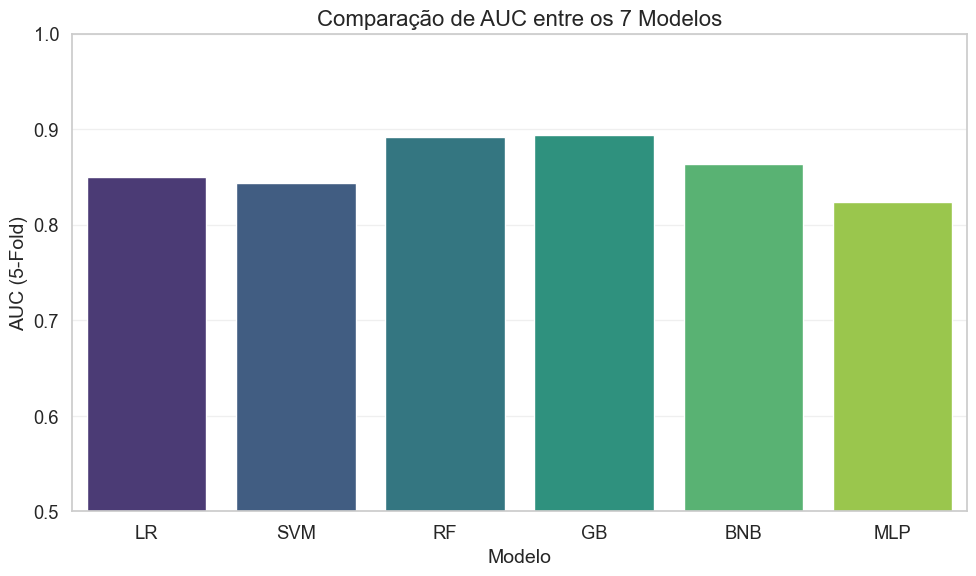


 Figura salva em: 5fold/auc_comparacao_7modelos.png


In [68]:


sns.set(style="whitegrid", font_scale=1.2)

def summarize_model(model_name):

    res = model_results[model_name]

    metrics = np.array(res["metrics"])
    auc_vals = np.array(res["auc"])

    mean_metrics = metrics.mean(axis=0)
    mean_auc = auc_vals.mean()

    return {
        "Model": model_name,
        "Accuracy":   mean_metrics[0],
        "Sensitivity":mean_metrics[1],
        "Specificity":mean_metrics[2],
        "PPV":        mean_metrics[7],
        "NPV":        mean_metrics[8],
        "AUC":        mean_auc
    }



models_james = ["LR", "SVM", "RF", "GB"]

df_james = pd.DataFrame([summarize_model(m) for m in models_james]).round(3)

print("\n=== MODELOS ORIGINAIS (JAMES) — 5-FOLD ===")
display(df_james)


models_new = [ "BNB","MLP"]

df_new = pd.DataFrame([summarize_model(m) for m in models_new]).round(3)

print("\n=== MODELOS NOVOS (Bernoulli, Gaussian, MLP) — 5-FOLD ===")
display(df_new)


df_all = pd.concat([df_james, df_new], ignore_index=True)

print("\n=== TABELA FINAL — TODOS OS MODELOS ===")
display(df_all)



plt.figure(figsize=(10,6))
sns.barplot(data=df_all, x='Model', y='AUC', palette='viridis')

plt.title("Comparação de AUC entre os 7 Modelos", fontsize=16)
plt.ylabel("AUC (5-Fold)", fontsize=14)
plt.xlabel("Modelo", fontsize=14)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("5fold/auc_comparacao_7modelos.png", dpi=300)
plt.show()

print("\n Figura salva em: 5fold/auc_comparacao_7modelos.png")


### Análises Pós-Modelagem (Exploratórias)

In [69]:
def analyze_and_plot_feature_importance(model_name, feature_importances_list, variable_names, top_n=40):
    
    feature_importances_array = np.array(feature_importances_list, dtype=float)
    if feature_importances_array.ndim == 1:
        feature_importances_array = feature_importances_array.reshape(1, -1)

    mean_importances = np.nanmean(np.abs(feature_importances_array), axis=0)

    if np.all(np.isnan(mean_importances)):
        print(f" Não foi possível calcular a importância média para {model_name}.")
        return None

    feature_importance_df = (
        pd.DataFrame({'Feature': variable_names, 'Importance': mean_importances})
        .sort_values(by='Importance', ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, max(6, top_n // 2)))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='crest')
    plt.title(f'Top {top_n} Features Mais Importantes — {model_name}', fontsize=14)
    plt.xlabel('Importância Média (|coef| ou Gini │ Permutation)', fontsize=12)
    plt.ylabel('Variável', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return feature_importance_df



---  Análise de Importância das Features (Média dos 5 Folds) ---

 Importância – LR


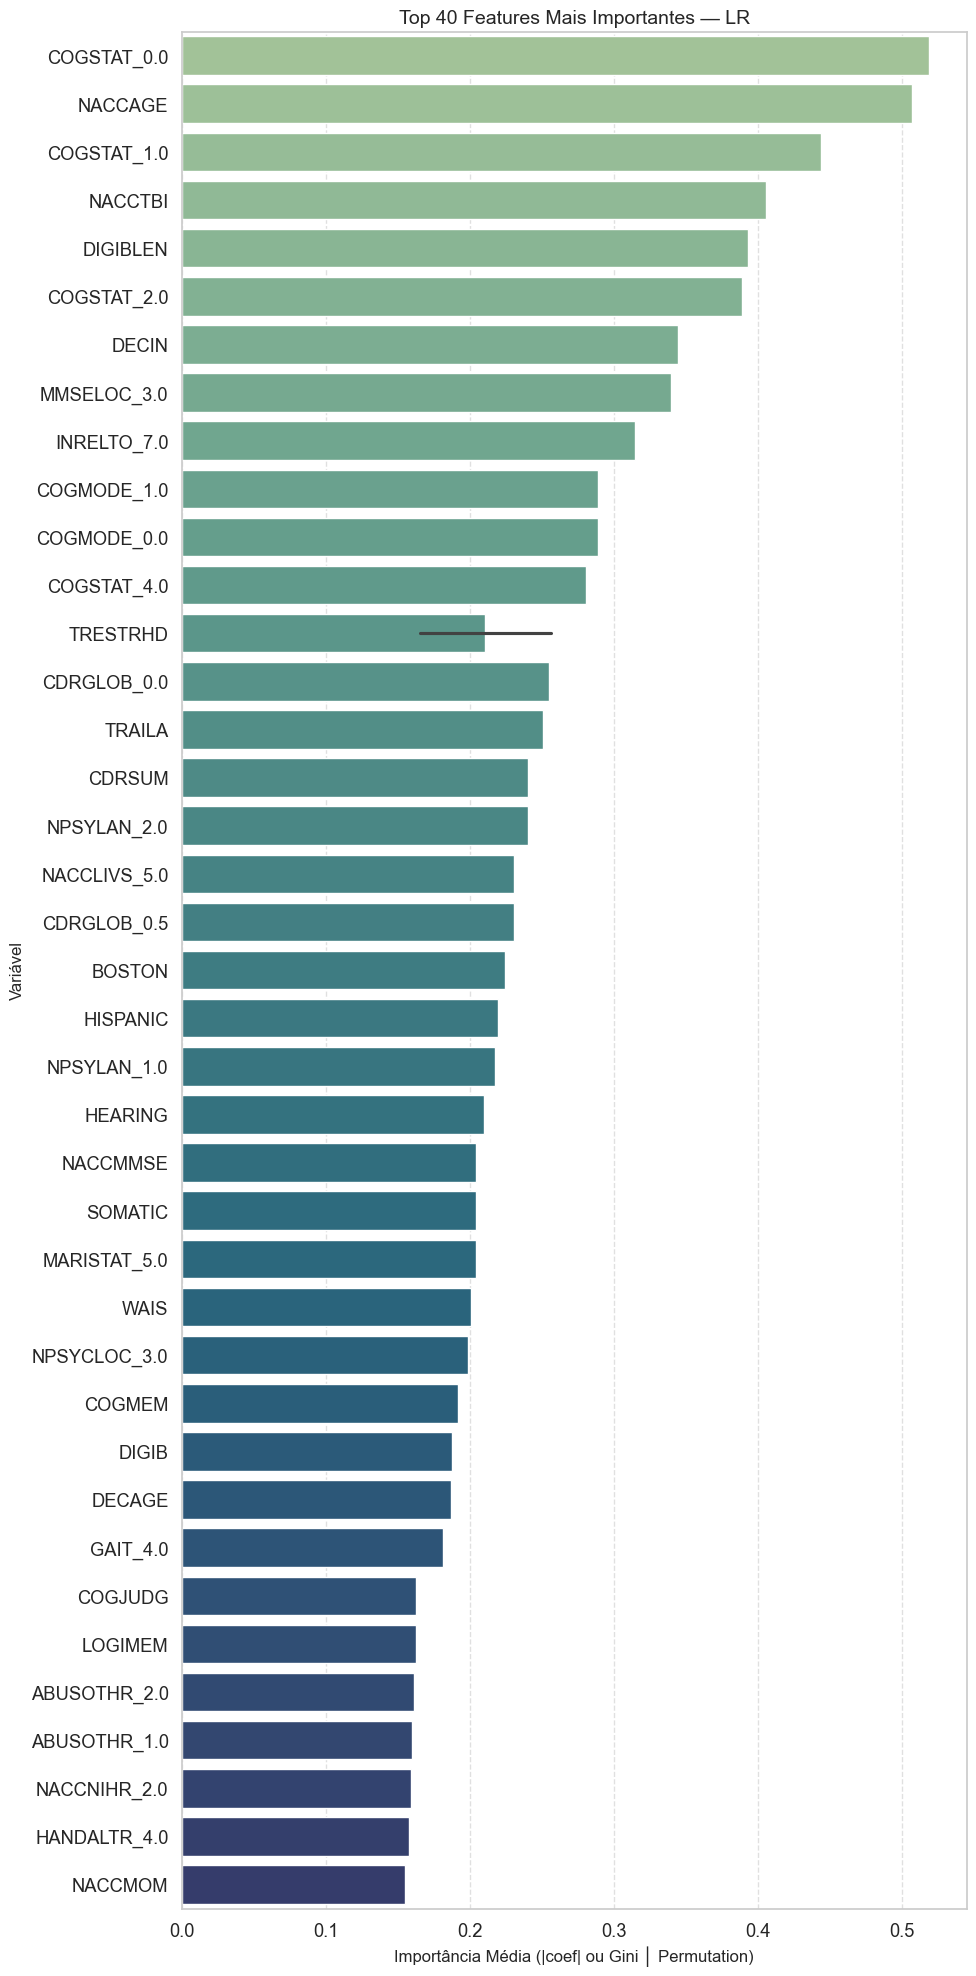


 Importância – SVM


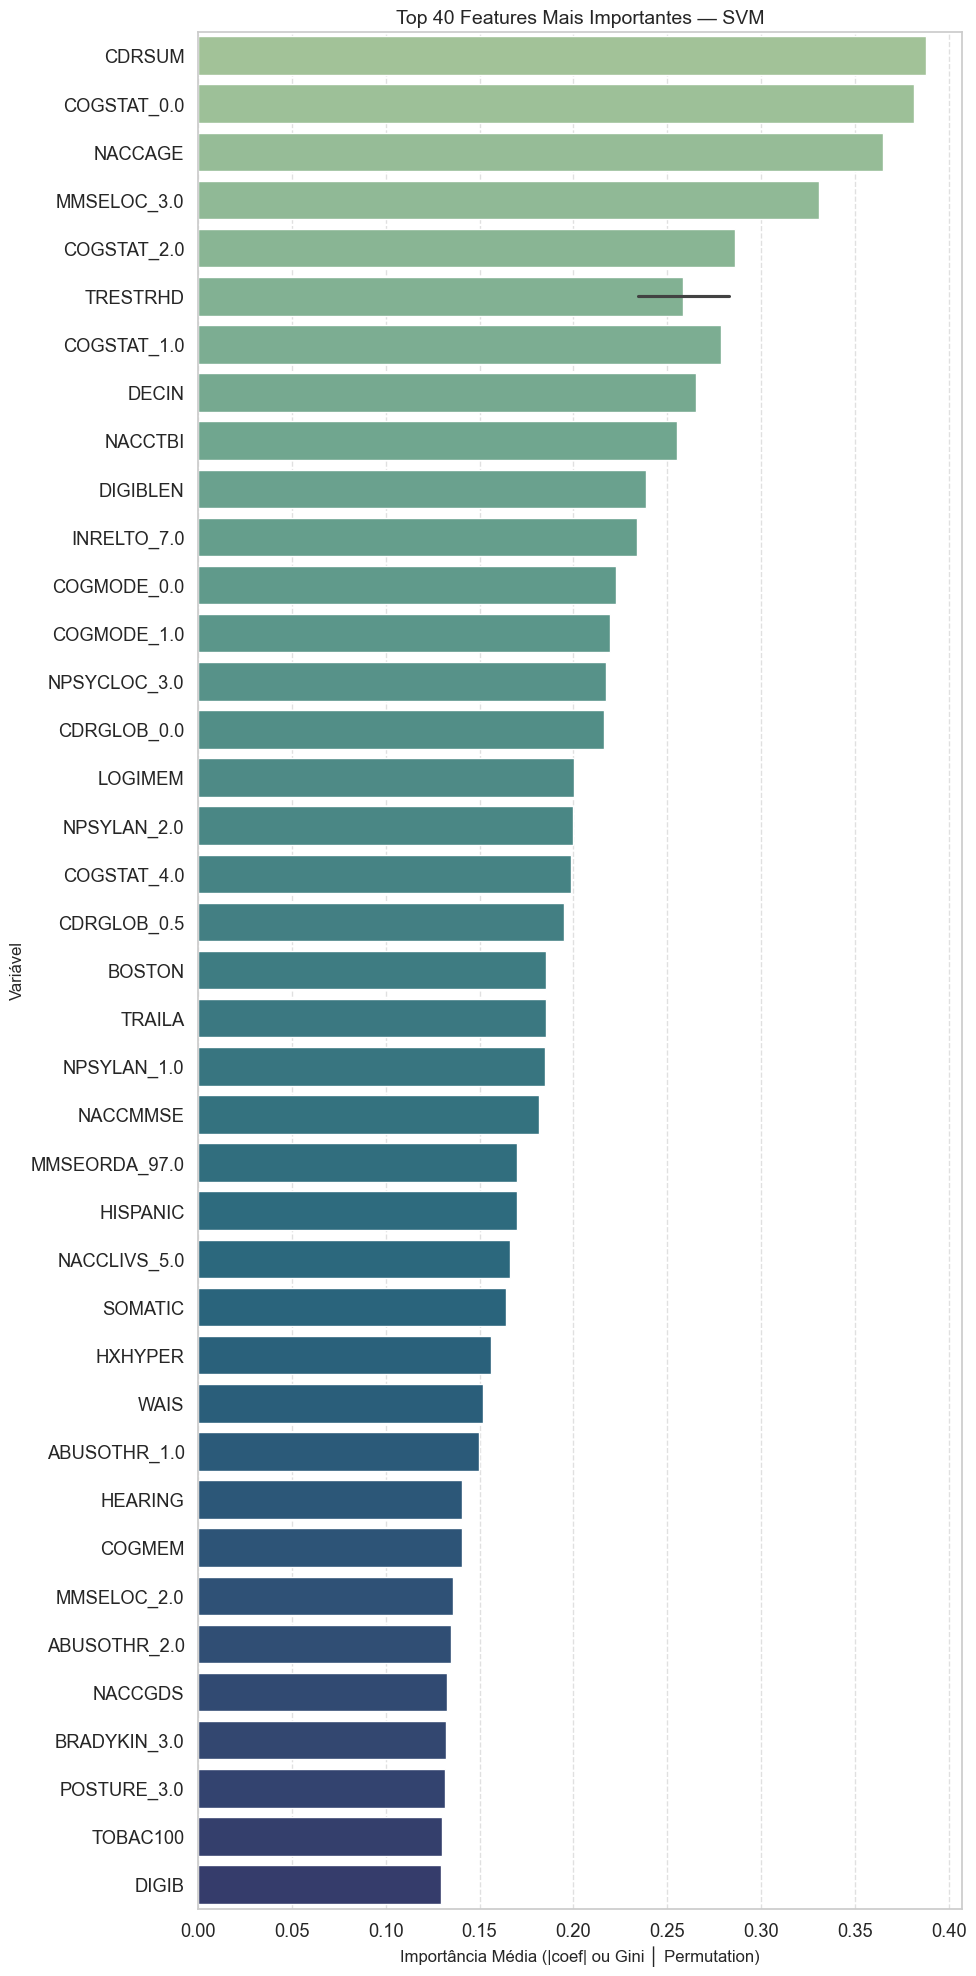


 Importância – RF


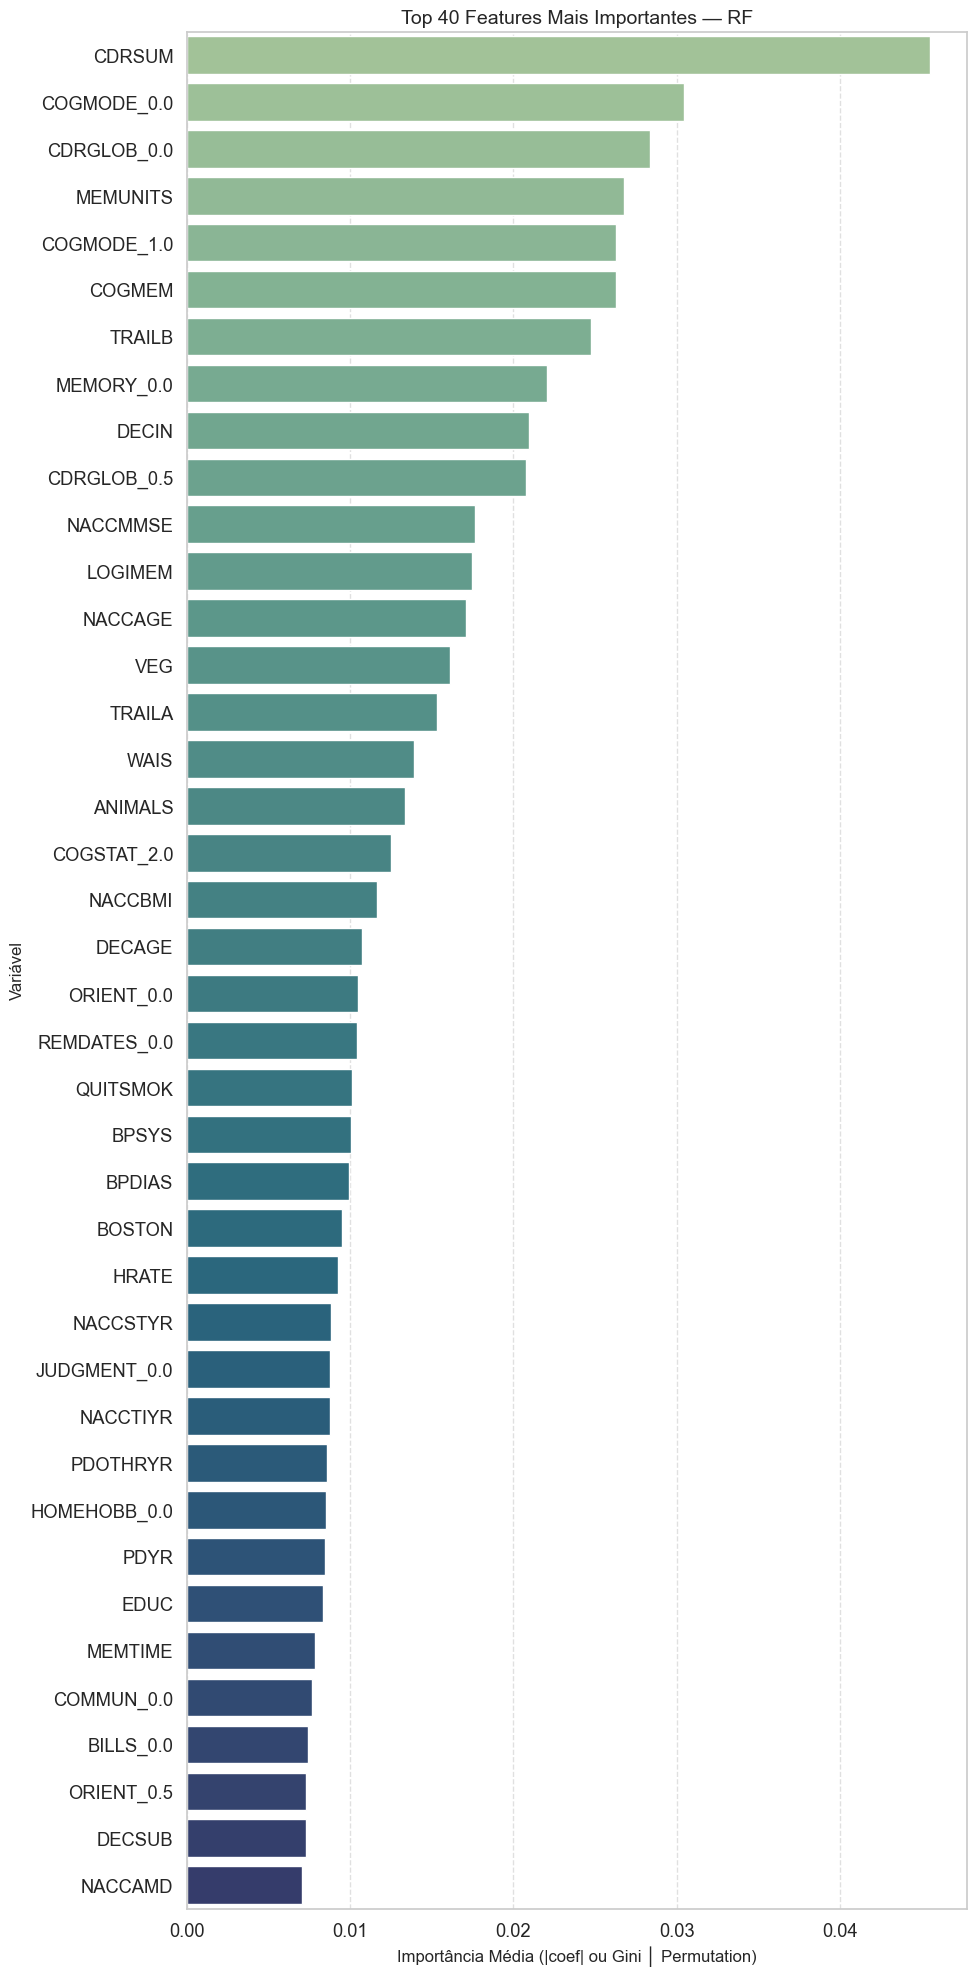


 Importância – GB


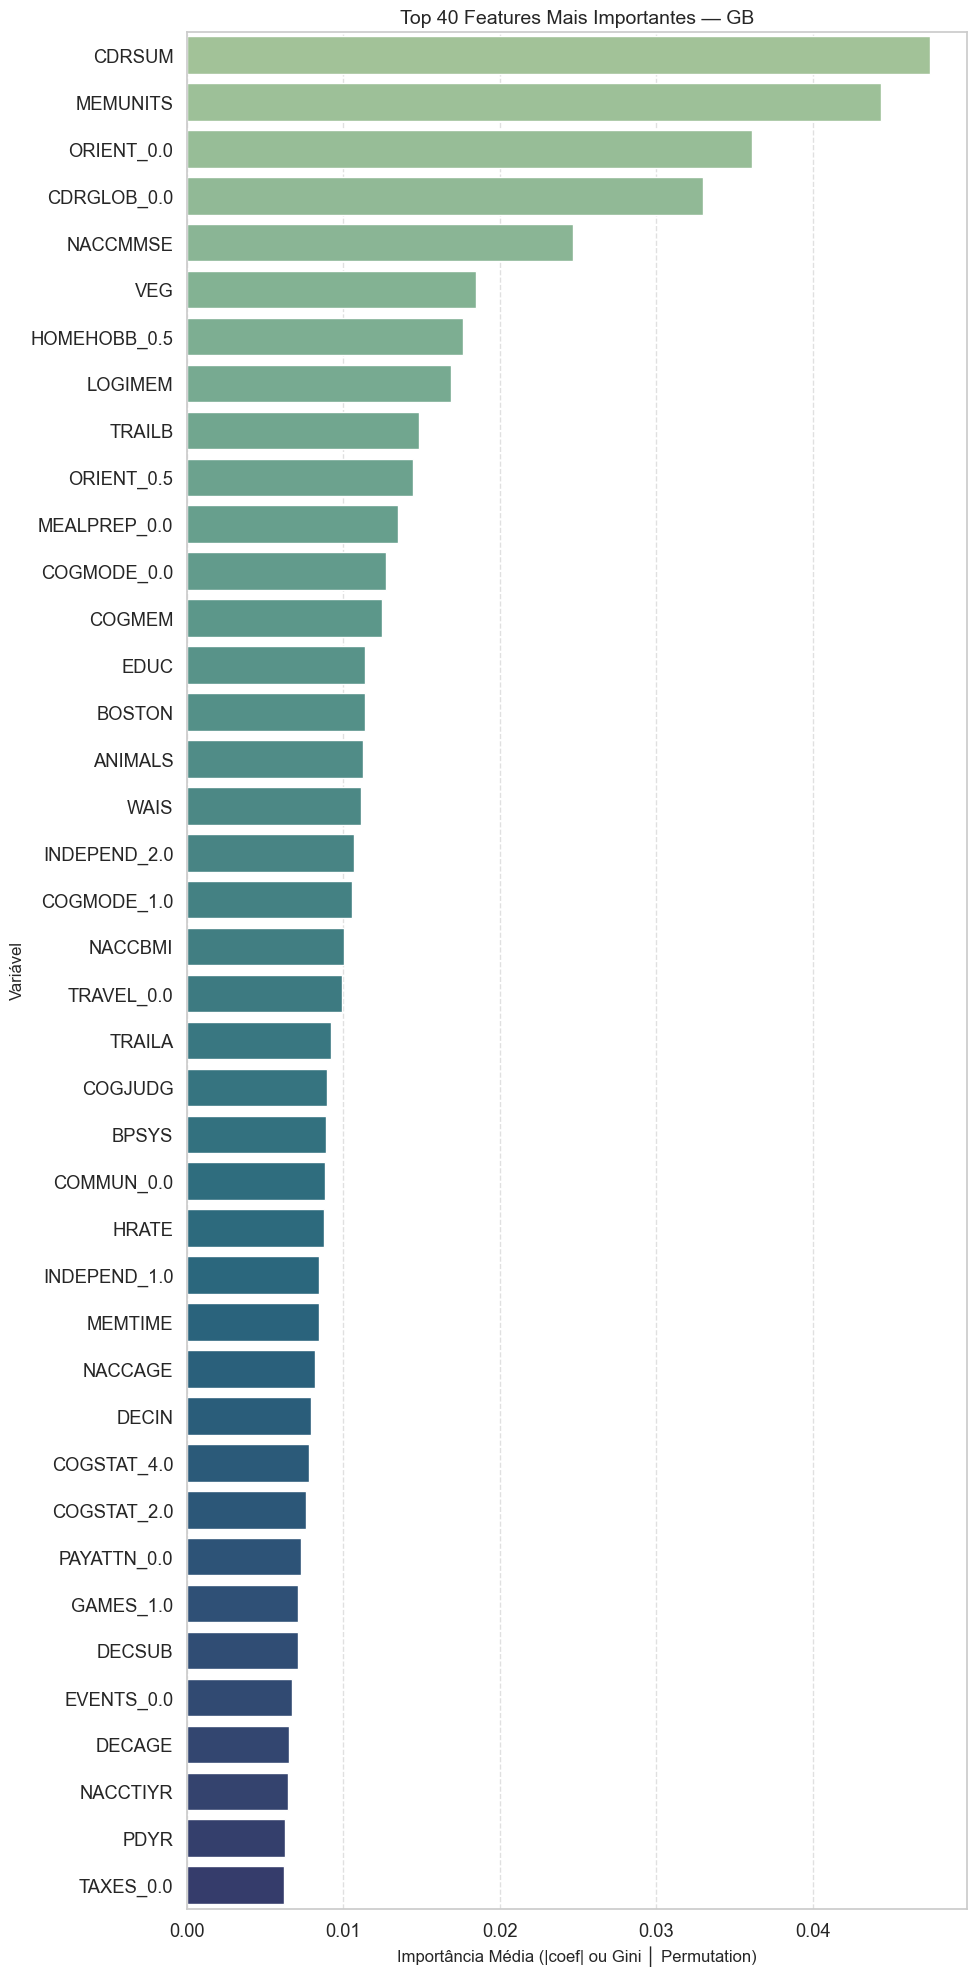


 Importância – BNB


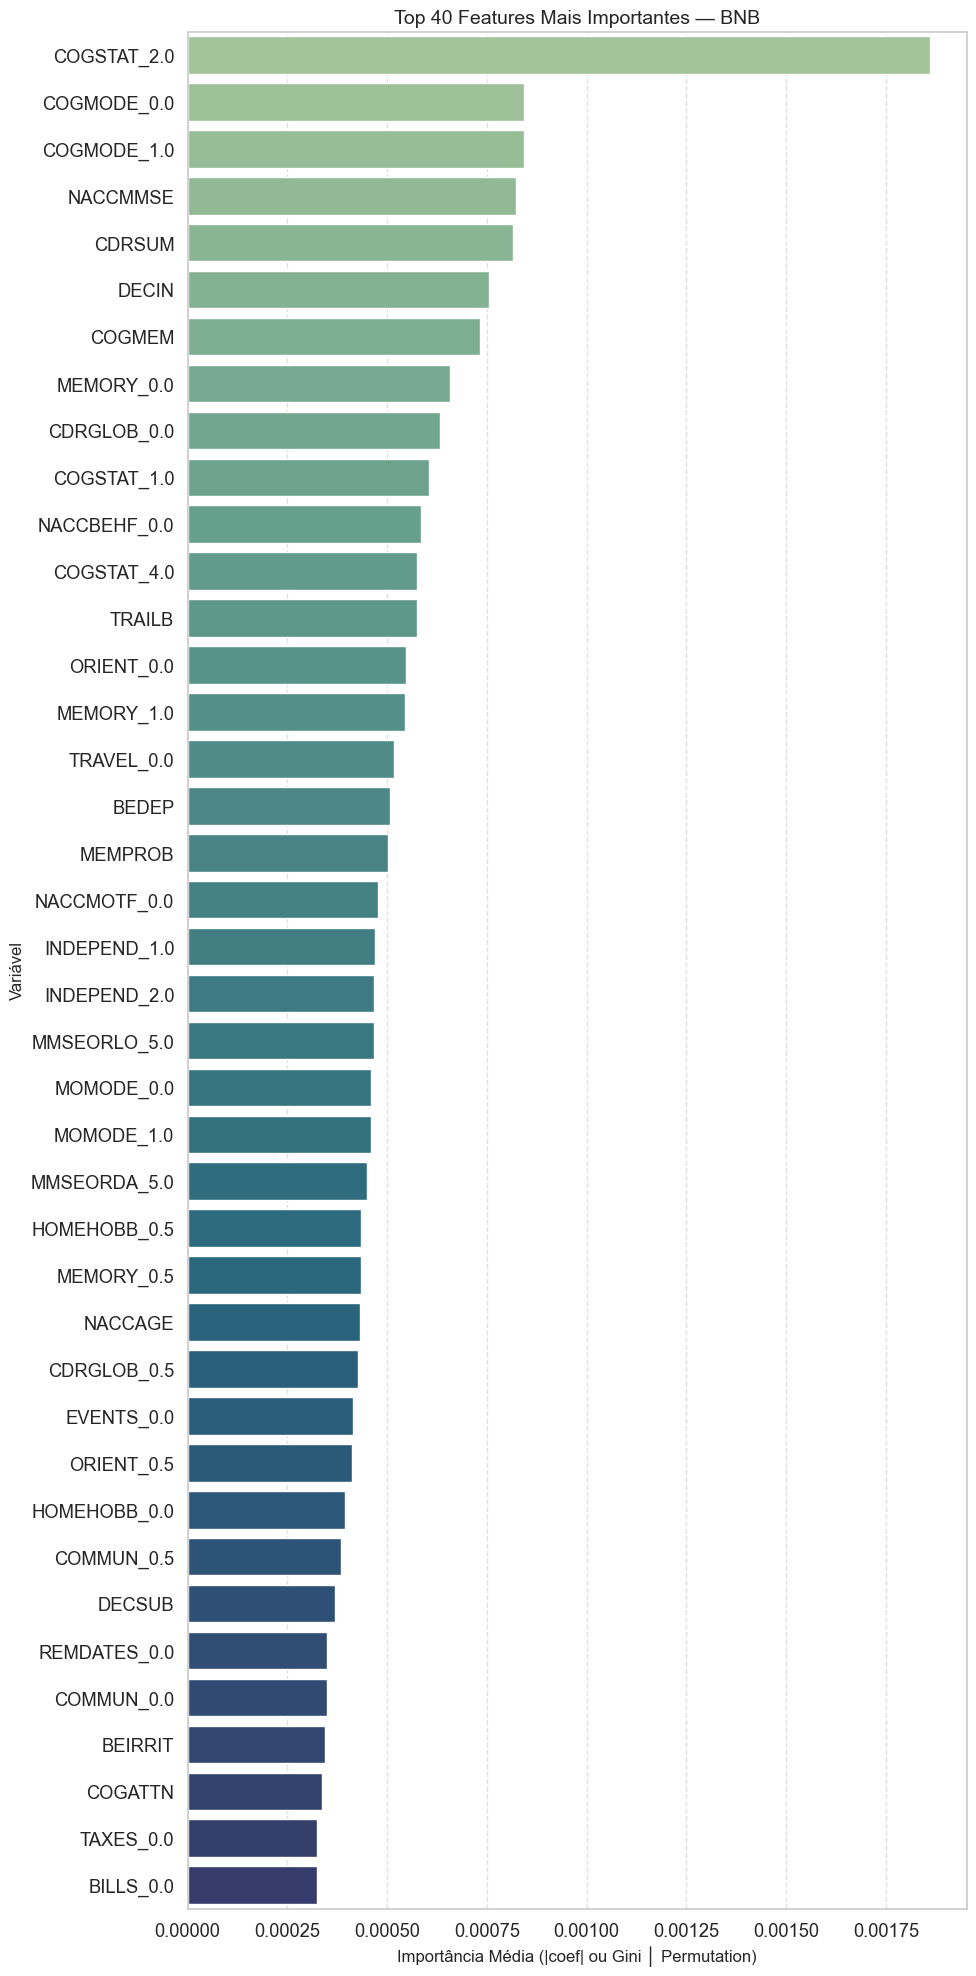


 Importância – MLP


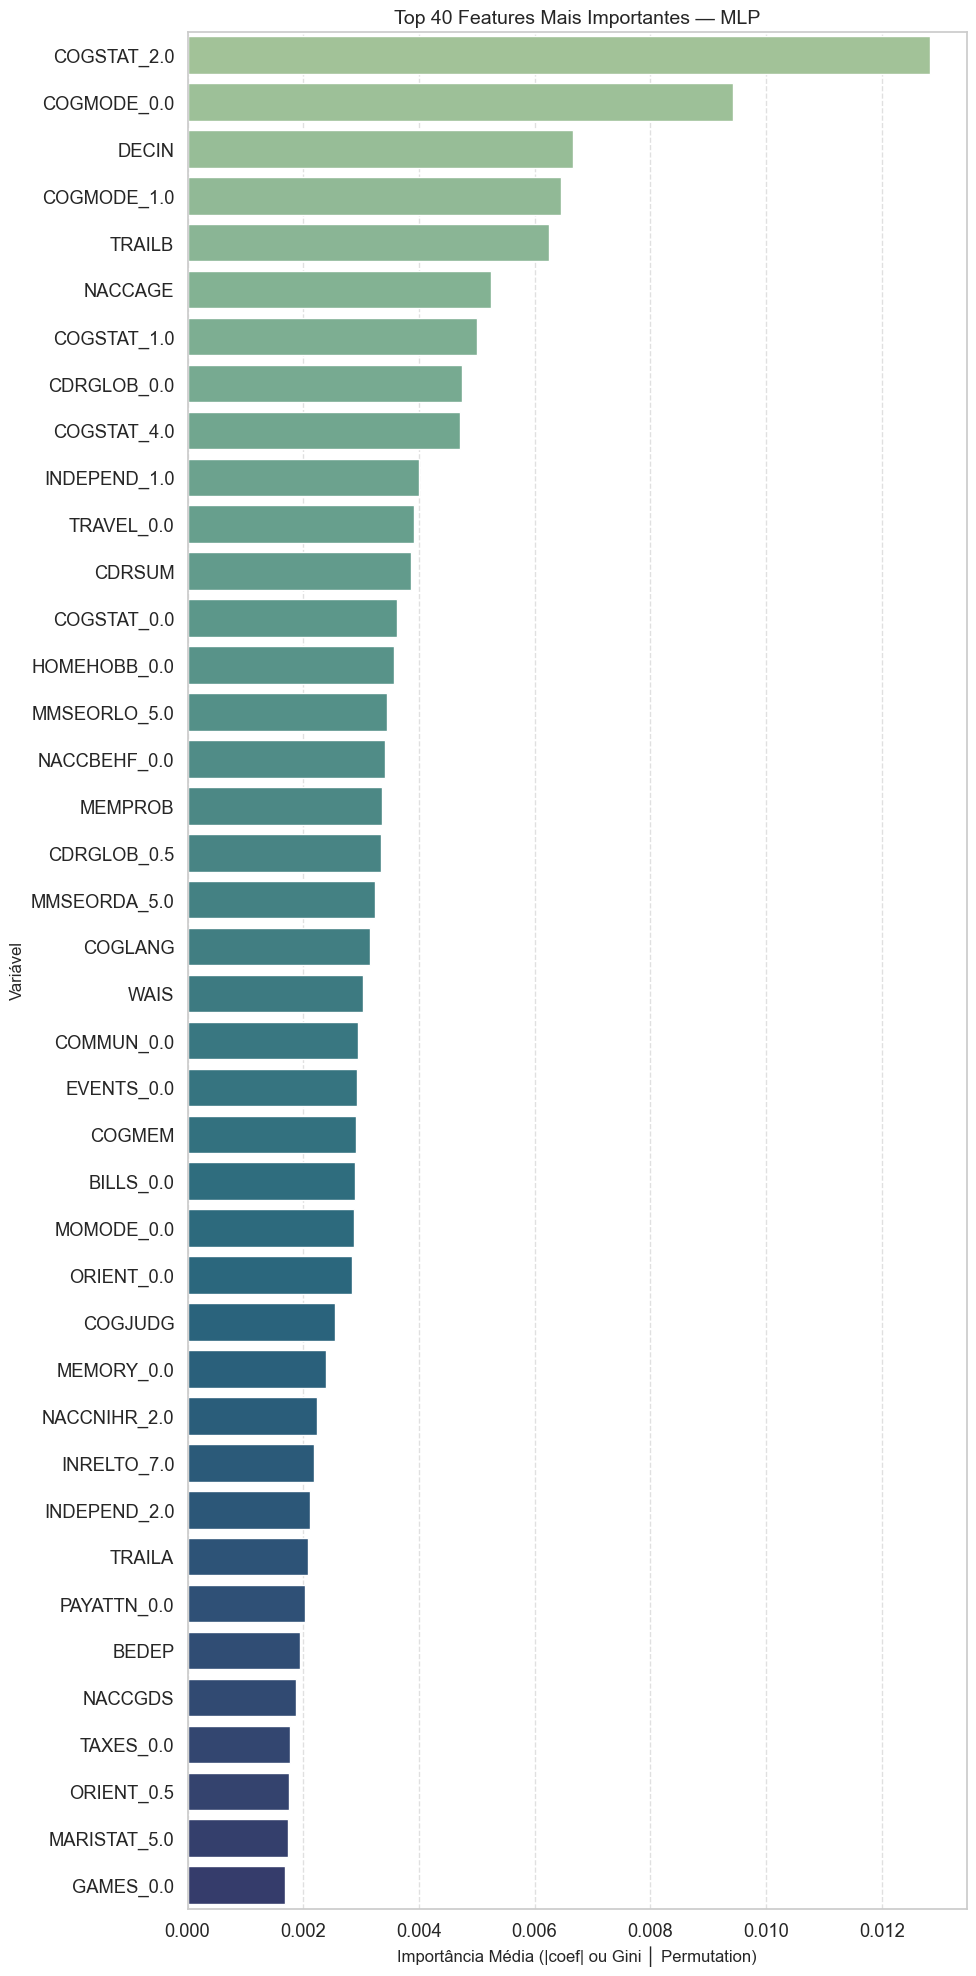

In [70]:
print("\n---  Análise de Importância das Features (Média dos 5 Folds) ---")

first_model = next(iter(model_results.values()))
variables = first_model["variables"]


for model_name in model_results.keys():

    feat_list = model_results[model_name]["feat"]

    print(f"\n Importância – {model_name}")
    analyze_and_plot_feature_importance(
        model_name,
        feat_list,
        variables,
        top_n=40
    )

In [71]:
os.chdir('./5fold/')  

In [72]:
print(" Carregando resultados dos modelos...\n")


lr_auc = model_results["LR"]["auc"]
svm_auc = model_results["SVM"]["auc"]
rf_auc = model_results["RF"]["auc"]
gb_auc = model_results["GB"]["auc"]
mlp_auc = model_results["MLP"]["auc"]

lr_metrics = model_results["LR"]["metrics"]
svm_metrics = model_results["SVM"]["metrics"]
rf_metrics = model_results["RF"]["metrics"]
gb_metrics = model_results["GB"]["metrics"]
mlp_metrics = model_results["MLP"]["metrics"]

lr_feat = model_results["LR"]["feat"]
svm_feat = model_results["SVM"]["feat"]
rf_feat = model_results["RF"]["feat"]
gb_feat = model_results["GB"]["feat"]
mlp_feat = model_results["MLP"]["feat"]

lr_probs = model_results["LR"]["probs"]
svm_probs = model_results["SVM"]["probs"]
rf_probs = model_results["RF"]["probs"]
gb_probs = model_results["GB"]["probs"]
mlp_probs = model_results["MLP"]["probs"]

lr_preds = model_results["LR"]["preds"]
svm_preds = model_results["SVM"]["preds"]
rf_preds = model_results["RF"]["preds"]
gb_preds = model_results["GB"]["preds"]
mlp_preds = model_results["MLP"]["preds"]

variables = model_results["LR"]["variables"]  

print(" Todos os modelos carregados com sucesso!")


 Carregando resultados dos modelos...

 Todos os modelos carregados com sucesso!


In [75]:
data = np.load('../encoded_data.npy')
outcome = np.load('../outcome.npy')

from sklearn.model_selection import StratifiedKFold as skf
sk = skf(n_splits=5)

true = []
for train, test in sk.split(data, outcome):
    true.extend(outcome[test])
true = np.array(true)


 Preparando probabilidades dos modelos...
 Probabilidades carregadas da memória!
Vetor verdadeiro reconstruído: 15974 entradas


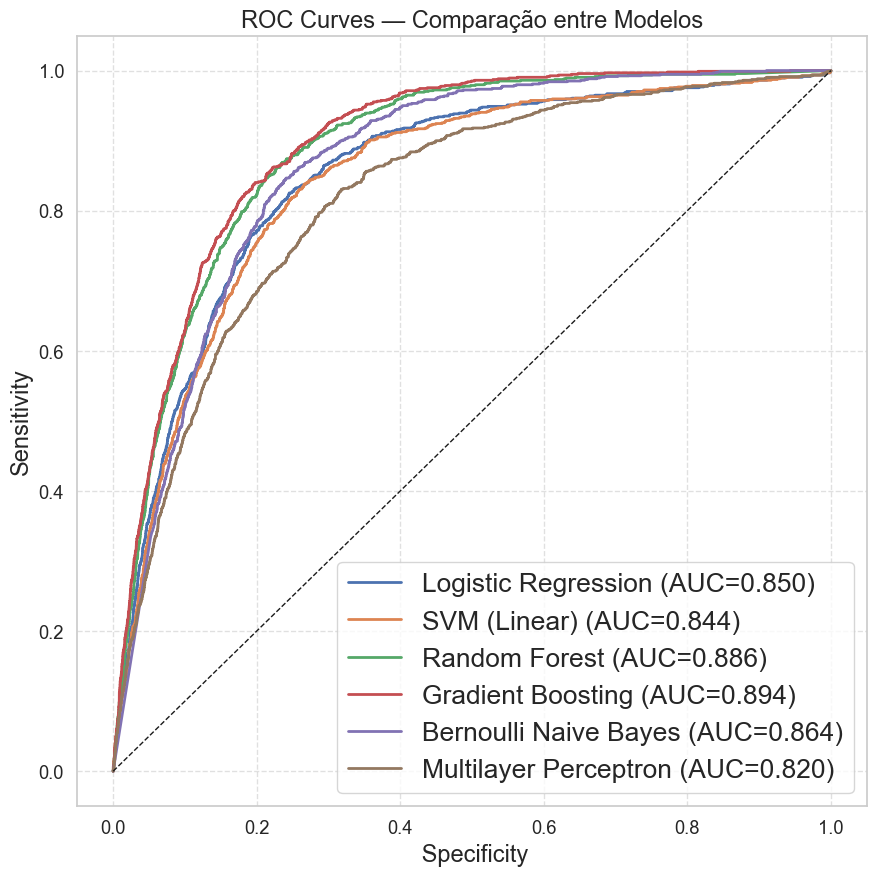

 Figura salva em 5fold/compare_auc_roc_models.svg


In [65]:

sns.set(style="whitegrid", font_scale=1.2)

print(" Preparando probabilidades dos modelos...")


probs_lr  = np.array(model_results["LR"]["probs"])
probs_svm = np.array(model_results["SVM"]["probs"])
probs_rf  = np.array(model_results["RF"]["probs"])
probs_gb  = np.array(model_results["GB"]["probs"])
probs_bnb = np.array(model_results["BNB"]["probs"])
probs_mlp = np.array(model_results["MLP"]["probs"])

print(" Probabilidades carregadas da memória!")


outcome = np.load("./outcome.npy")

def rebuild_true_vector(outcome, n_splits=5):
    sk = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    true_concat = []
    for _, test_idx in sk.split(np.zeros_like(outcome), outcome):
        true_concat.extend(outcome[test_idx])
    return np.array(true_concat)

true_all = rebuild_true_vector(outcome)

print(f"Vetor verdadeiro reconstruído: {len(true_all)} entradas")


def plot_roc(probs_list, true_list, labels):
    plt.figure(figsize=(9, 9))

    for prob, label in zip(probs_list, labels):
        fpr, tpr, _ = roc_curve(true_list, prob)
        auc_val = roc_auc_score(true_list, prob)

        plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC={auc_val:.3f})")

    xx = np.linspace(0, 1, 100)
    plt.plot(xx, xx, 'k--', linewidth=1)

    plt.xlabel(" Specificity", fontsize=17)
    plt.ylabel("Sensitivity", fontsize=17)
    plt.title("ROC Curves — Comparação entre Modelos", fontsize=17)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(
    loc='lower right',
    fontsize=19,           
    title_fontsize=21,     
)
    plt.tight_layout()

    plt.savefig("compare_auc_roc_models.svg", dpi=300)

    plt.show()

    print(" Figura salva em 5fold/compare_auc_roc_models.svg")

probs = [
    probs_lr,
    probs_svm,
    probs_rf,
    probs_gb,
    probs_bnb,
    probs_mlp
]

labels = [
    "Logistic Regression",
    "SVM (Linear)",
    "Random Forest",
    "Gradient Boosting",
    "Bernoulli Naive Bayes",
    "Multilayer Perceptron"
]


plot_roc(probs, true_all, labels)



 Calculando AUC × Nº Features para LR...
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold/lr_auc_low_hi_med.npy


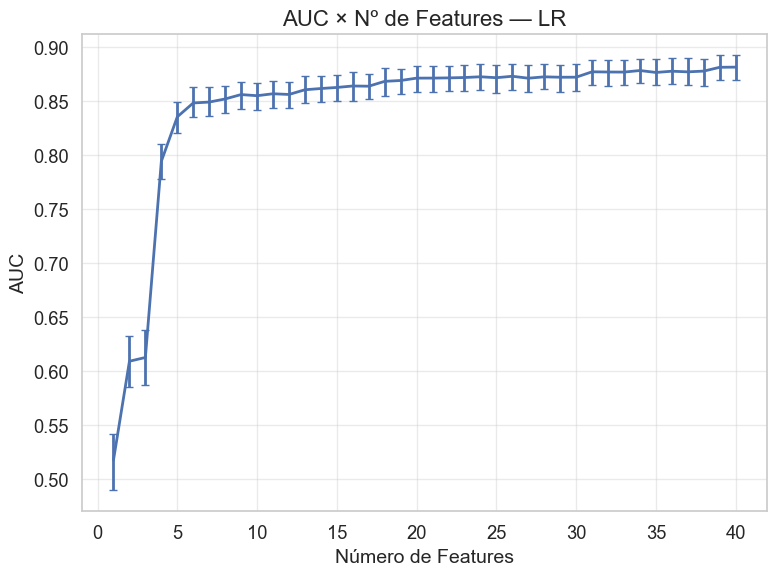


 Calculando AUC × Nº Features para SVM...
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold/svm_auc_low_hi_med.npy


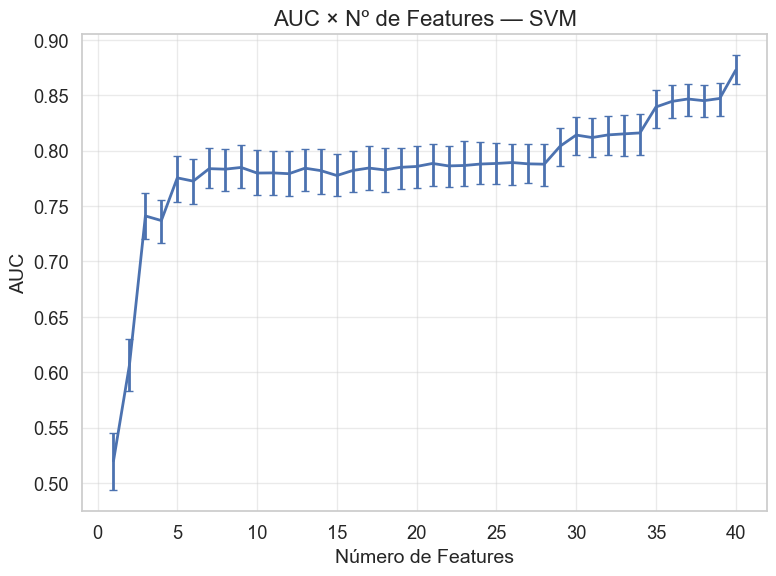


 Calculando AUC × Nº Features para RF...
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold/rf_auc_low_hi_med.npy


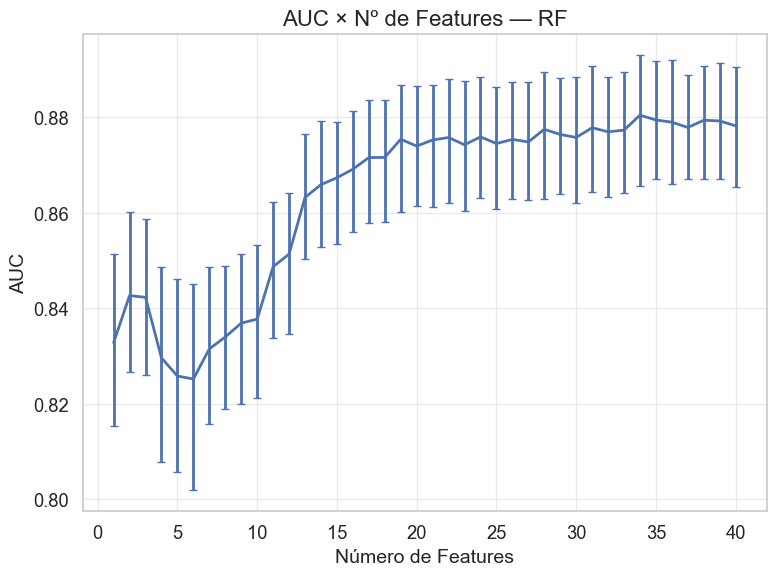


 Calculando AUC × Nº Features para GB...
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold/gb_auc_low_hi_med.npy


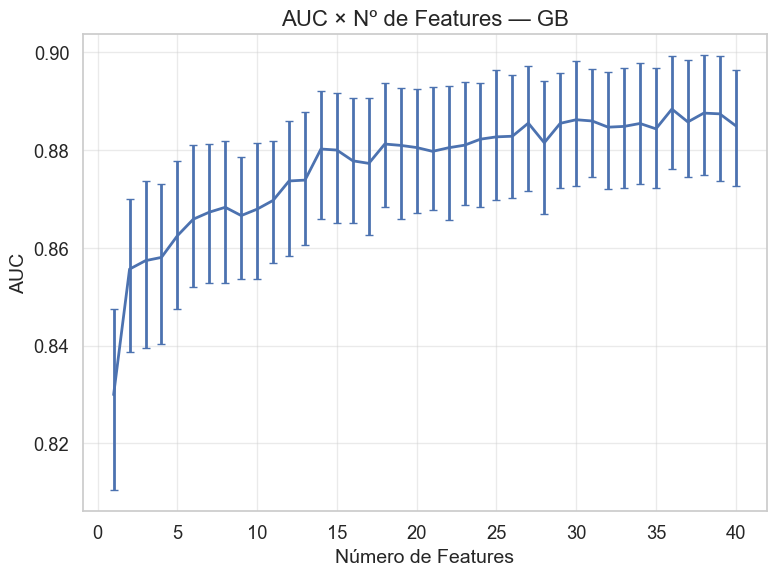


 Calculando AUC × Nº Features para BNB...
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold/bnb_auc_low_hi_med.npy


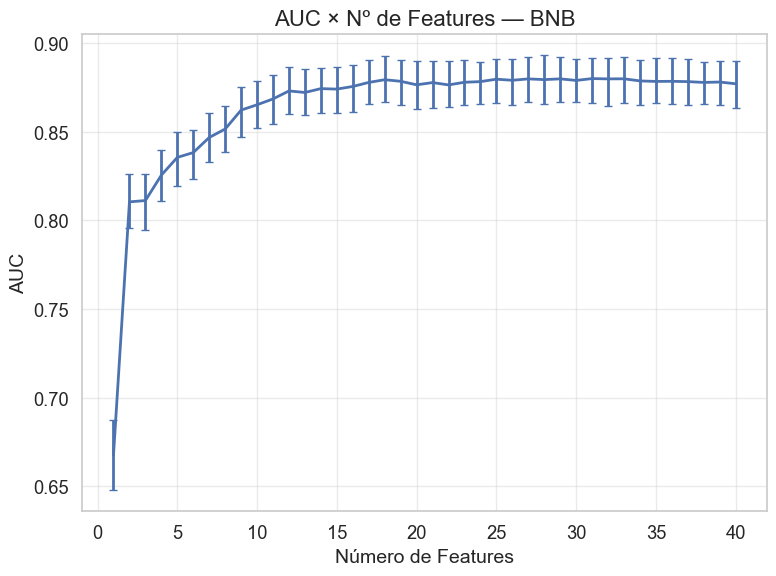


 Calculando AUC × Nº Features para MLP...
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold/mlp_auc_low_hi_med.npy


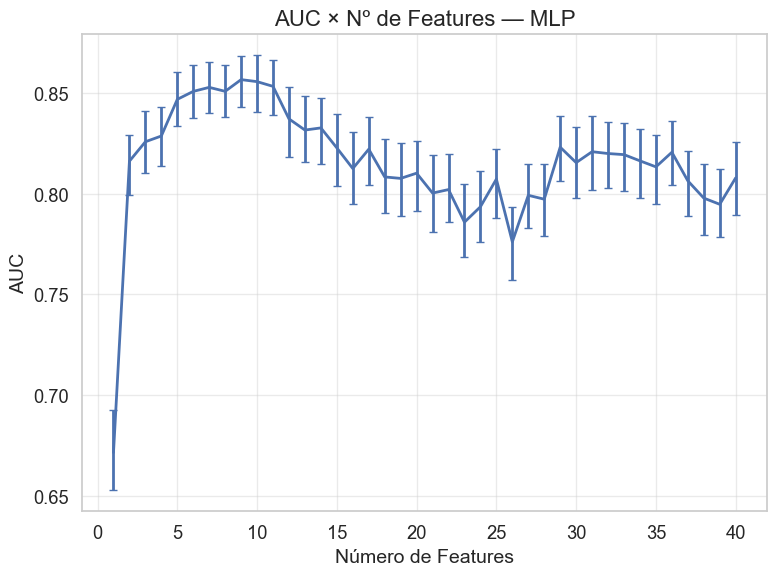

In [78]:
def bootstrap_auc(probability, classes, n_iter=1000, sample_size=1000):
    auc_vals = []
    n = len(classes)
    for _ in range(n_iter):
        idx = np.random.randint(0, n, size=min(sample_size, n))
        auc_vals.append(
            roc_auc_score(classes[idx], probability[idx])
        )
    return (
        np.percentile(auc_vals, 25),
        np.percentile(auc_vals, 75),
        np.median(auc_vals)
    )


def auc_feat(models, feat_importance, X_data, y_data, n_features=40):

    idx = np.argsort(-feat_importance)
    sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    auc_vals, lows, highs, meds = [], [], [], []

    for k in range(1, n_features + 1):

        print(f"{k} features...")

        feats = idx[:k]
        probs, true = [], []
        fold = 0

        for train_idx, test_idx in sk.split(X_data, y_data):
            model = models[fold]

            X_train = X_data[train_idx][:, feats]
            X_test  = X_data[test_idx][:, feats]
            y_train = y_data[train_idx]
            y_test  = y_data[test_idx]

            model.fit(X_train, y_train)
            prob = model.predict_proba(X_test)[:, 1]

            probs.extend(prob)
            true.extend(y_test)
            fold += 1

        auc_val = roc_auc_score(true, probs)
        l, h, m = bootstrap_auc(np.array(probs), np.array(true))
        
        auc_vals.append(auc_val)
        lows.append(l)
        highs.append(h)
        meds.append(m)

    return auc_vals, lows, meds, highs



model_list = {
    "LR":  model_results["LR"],
    "SVM": model_results["SVM"],
    "RF":  model_results["RF"],
    "GB":  model_results["GB"],
    "BNB": model_results["BNB"],
    "MLP": model_results["MLP"]
}



X_final = np.load("../encoded_data.npy")
y_final = np.load("../outcome.npy")

for short_name, data in model_list.items():

    print(f"\n Calculando AUC × Nº Features para {short_name}...")

    models = data["models"]
    feat   = data["feat"]

    mean_feat = np.mean(feat, axis=0)

    a, l, m, h = auc_feat(models, mean_feat, X_final, y_final, n_features=40)

    np.save(f"{short_name.lower()}_auc_low_hi_med.npy", [a, l, m, h])

    print(f" Salvo: 5fold/{short_name.lower()}_auc_low_hi_med.npy")


    x = list(range(1, 41))
    plt.figure(figsize=(8, 6))
    plt.errorbar(
        x, m,
        yerr=np.vstack((
            np.array(m) - np.array(l),
            np.array(h) - np.array(m)
        )),
        alpha=1, linewidth=2, capsize=3
    )
    plt.xlabel("Número de Features", fontsize=14)
    plt.ylabel("AUC", fontsize=14)
    plt.title(f"AUC × Nº de Features — {short_name}", fontsize=16)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()

    plt.savefig(f"{short_name.lower()}_auc_vs_features.png", dpi=300)
    plt.show()


 Carregando importâncias diretamente do model_results...

 Importâncias carregadas do model_results!

 Top 40 variáveis por modelo:


,LR,SVM,RF,XGB,BNB,MLP
0,COGSTAT_0.0,CDRSUM,CDRSUM,CDRSUM,COGSTAT_2.0,COGSTAT_2.0
1,NACCAGE,COGSTAT_0.0,COGMODE_0.0,MEMUNITS,COGMODE_0.0,COGMODE_0.0
2,COGSTAT_1.0,NACCAGE,CDRGLOB_0.0,ORIENT_0.0,COGMODE_1.0,DECIN
3,NACCTBI,MMSELOC_3.0,MEMUNITS,CDRGLOB_0.0,NACCMMSE,COGMODE_1.0
4,DIGIBLEN,COGSTAT_2.0,COGMODE_1.0,NACCMMSE,CDRSUM,TRAILB
5,COGSTAT_2.0,TRESTRHD,COGMEM,VEG,DECIN,NACCAGE
6,DECIN,COGSTAT_1.0,TRAILB,HOMEHOBB_0.5,COGMEM,COGSTAT_1.0
7,MMSELOC_3.0,DECIN,MEMORY_0.0,LOGIMEM,MEMORY_0.0,CDRGLOB_0.0
8,INRELTO_7.0,NACCTBI,DECIN,TRAILB,CDRGLOB_0.0,COGSTAT_4.0
9,COGMODE_1.0,DIGIBLEN,CDRGLOB_0.5,ORIENT_0.5,COGSTAT_1.0,INDEPEND_1.0


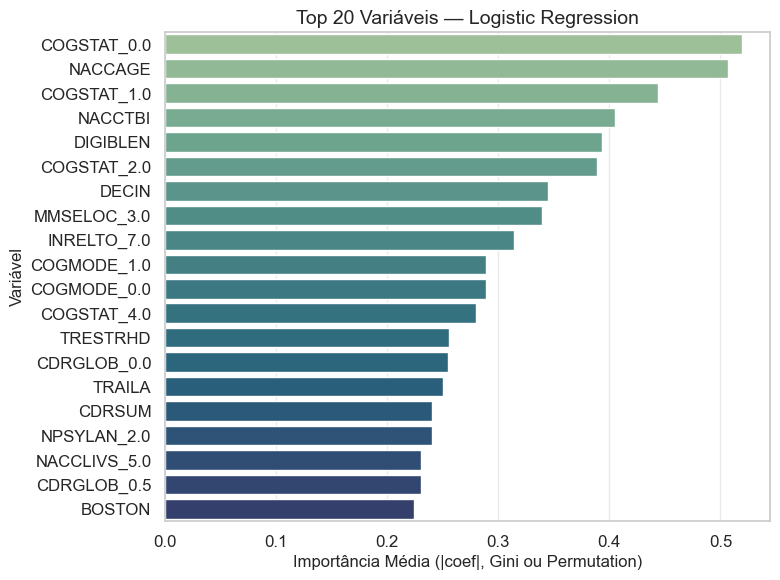

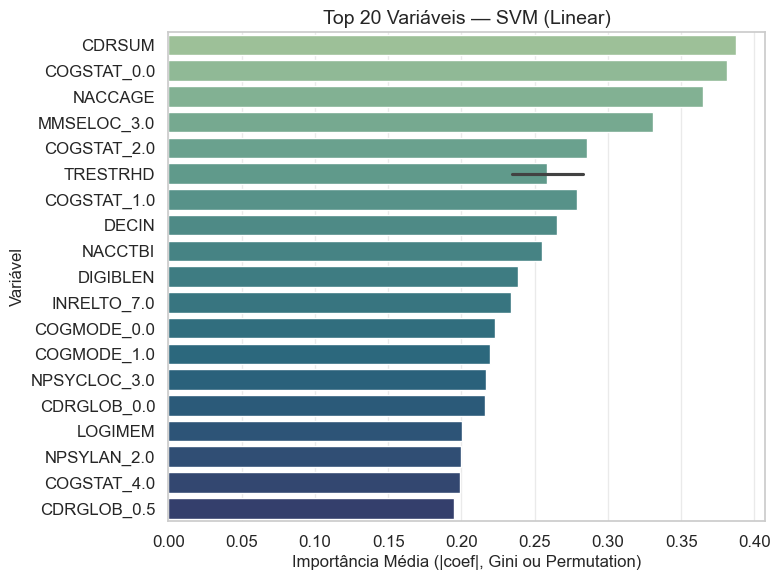

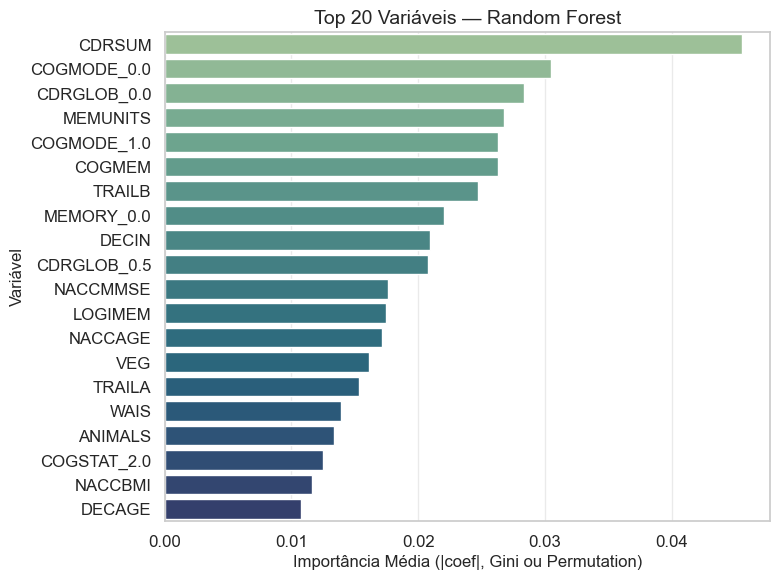

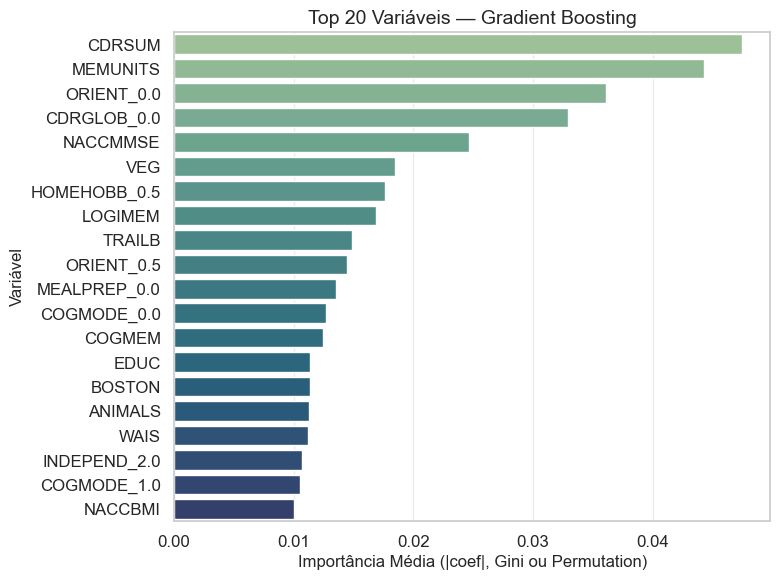

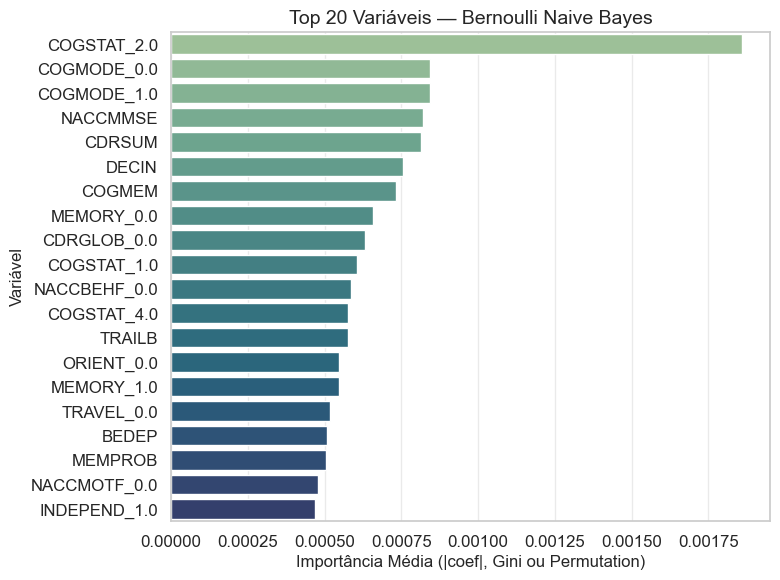

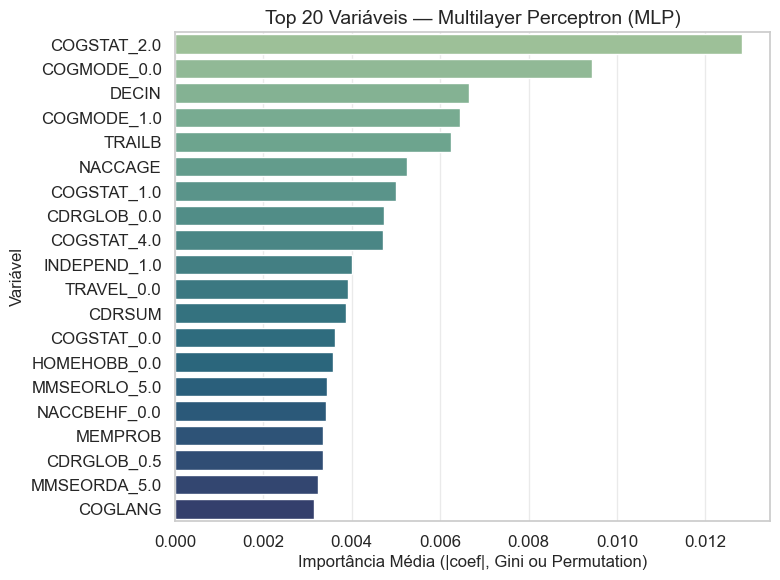

In [81]:
sns.set(style="whitegrid", font_scale=1.1)

print(" Carregando importâncias diretamente do model_results...\n")


lr_feat  = model_results["LR"]["feat"]
svm_feat = model_results["SVM"]["feat"]
rf_feat  = model_results["RF"]["feat"]
xgb_feat = model_results["GB"]["feat"]
bnb_feat = model_results["BNB"]["feat"]
mlp_feat = model_results["MLP"]["feat"]   

variables = model_results["LR"]["variables"]   

print(" Importâncias carregadas do model_results!\n")


def importances_df(models, importances, n_feat, variables):
    df = pd.DataFrame()
    for name, imp in zip(models, importances):
        
        imp_mean = np.mean(np.abs(imp), axis=0)
        idx_sorted = np.argsort(-imp_mean)
        
        df[name] = [variables[i] for i in idx_sorted[:n_feat]]

    return df


model_names = ["LR", "SVM", "RF", "XGB", "BNB", "MLP"]
importances_all = [lr_feat, svm_feat, rf_feat, xgb_feat, bnb_feat, mlp_feat]

features_df = importances_df(model_names, importances_all, n_feat=40, variables=variables)

print(" Top 40 variáveis por modelo:")
display(features_df.head(10))



def plot_feature_importance(model_name, feat_list, variables, top_n=20):
    
    imp_mean = np.mean(np.abs(feat_list), axis=0)
    idx_sorted = np.argsort(-imp_mean)[:top_n]

    top_vars = np.array(variables)[idx_sorted]
    top_scores = imp_mean[idx_sorted]

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_scores, y=top_vars, palette="crest")
    
    plt.title(f"Top {top_n} Variáveis — {model_name}", fontsize=14)
    plt.xlabel("Importância Média (|coef|, Gini ou Permutation)", fontsize=12)
    plt.ylabel("Variável", fontsize=12)
    plt.grid(axis="x", alpha=0.4)
    plt.tight_layout()
    plt.show()



plot_feature_importance("Logistic Regression", lr_feat, variables)
plot_feature_importance("SVM (Linear)", svm_feat, variables)
plot_feature_importance("Random Forest", rf_feat, variables)
plot_feature_importance("Gradient Boosting", xgb_feat, variables)
plot_feature_importance("Bernoulli Naive Bayes", bnb_feat, variables)
plot_feature_importance("Multilayer Perceptron (MLP)", mlp_feat, variables)


In [4]:
import os
print(os.getcwd())


/Users/eduardafigueredo/tcc-parkinson-dementia-ml


Arquivos encontrados: ['svm_auc_low_hi_med.npy', 'gb_auc_low_hi_med.npy', 'lr_auc_low_hi_med.npy', 'mlp_auc_low_hi_med.npy', 'rf_auc_low_hi_med.npy', 'bnb_auc_low_hi_med.npy']


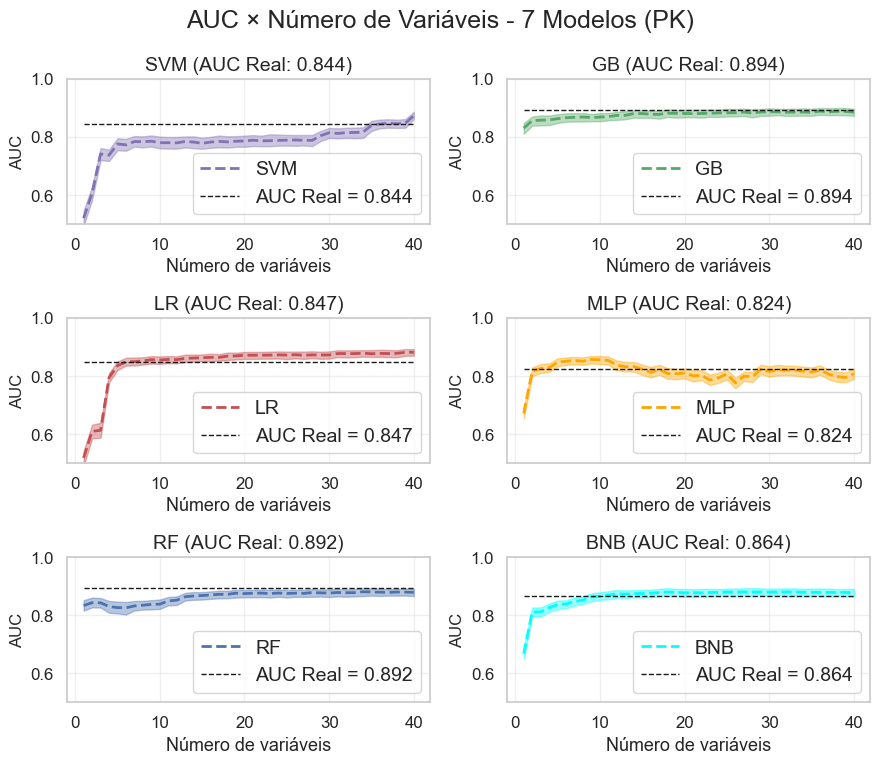

 Figura salva em: 5fold/auc_vs_features_all.png


In [ ]:

true_auc = {}


for model in ["lr", "svm", "rf", "gb","bnb", "mlp"]:
    pkl_path = f"5fold/{model}_results.pkl"
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    auc_folds = data[0]          
    true_auc[model] = float(np.mean(auc_folds))


sns.set(style="whitegrid", font_scale=1.1)

valid_models = ['lr', 'svm', 'rf', 'gb', "bnb", 'mlp']

files= [
    f for f in os.listdir('5fold')
    if f.endswith('_auc_low_hi_med.npy') and f.split('_')[0] in valid_models
]
print(f"Arquivos encontrados: {files}")

auc_vals, low, high, med, name = [], [], [], [], []

for f in files:
    a, l, m, h = np.load(os.path.join('5fold', f), allow_pickle=True)


    short = f.split('_')[0]
    name.append(short)


    a, l, m, h = [
        np.concatenate(([0.5], x)) for x in [a, l, m, h]
    ]

    auc_vals.append(a)
    low.append(l)
    high.append(h)
    med.append(m)

short2name = {
    'lr': 'LR',
    'svm': 'SVM',
    'rf': 'RF',
    'gb': 'GB',
    'bnb': 'BNB',
    'mlp': 'MLP'
}

colors= {
    'lr': 'r',
    'svm': 'm',
    'rf': 'b',
    'gb': 'g',
    'bnb': 'cyan',
    'mlp': 'orange'
}

def plot_auc_feat(auc, low, med, high, name, i, col, ax):
    a, l, h, m = (
        auc[i][1:41],
        low[i][1:41],
        high[i][1:41],
        med[i][1:41],
    )

    x = list(range(1, len(a) + 1))

    modelo_short = name[i]
    modelo_label = short2name[modelo_short]

    final_auc = true_auc[modelo_short]

    ax.plot(x, m, '--', linewidth=2, color=col, label=modelo_label)
    ax.fill_between(x, l, h, alpha=0.4, color=col)

    ax.plot(
        x,
        np.ones(len(x)) * final_auc,
        'k--',
        label=f"AUC Real = {final_auc:.3f}",
        linewidth=1
    )

    ax.set_ylim(0.5, 1)
    ax.set_xlabel('Número de variáveis', fontsize=13)
    ax.set_ylabel('AUC', fontsize=12)
    ax.legend(
    loc='lower right',
    fontsize=14,           
    title_fontsize=15,     
)
    ax.grid(alpha=0.3)
    ax.set_title(f"{modelo_label} (AUC Real: {final_auc:.3f})", fontsize=14)


num_models = len(files)
cols = 2
rows = int(np.ceil(num_models / cols))

fig = plt.figure(figsize=(9, 2.6 * rows))

spec = gridspec.GridSpec(ncols=cols, nrows=rows, figure=fig)

for i in range(num_models):
    ax = fig.add_subplot(spec[i])
    col = colors[name[i]]
    plot_auc_feat(auc_vals, low, med, high, name, i, col, ax)


plt.suptitle('AUC × Número de Variáveis - 7 Modelos (PK)', fontsize=18)
plt.tight_layout()
plt.savefig("auc_vs_features_all.png", dpi=300)
plt.show()

print(" Figura salva em: 5fold/auc_vs_features_all.png")


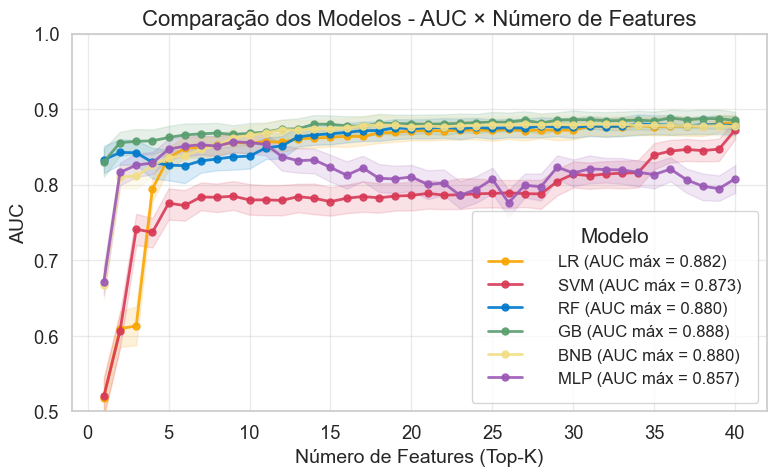


Figura salva em: 5fold/auc_vs_features_comparison.png


In [ ]:
sns.set(style="whitegrid", font_scale=1.2)

result_dir = "5fold"

models = ['LR', 'SVM', 'RF', 'GB','BNB','MLP']

colors = {
    'LR': '#F9A602',
    'SVM': "#D83A56",
    'RF': '#007ACC',
    'GB': '#5A9E6F',
    'BNB': "#F1DE87",
    'MLP': '#9B59B6'
    
}

files = {
    'LR':  os.path.join(result_dir, 'lr_auc_low_hi_med.npy'),
    'SVM': os.path.join(result_dir, 'svm_auc_low_hi_med.npy'),
    'RF':  os.path.join(result_dir, 'rf_auc_low_hi_med.npy'),
    'GB': os.path.join(result_dir, 'gb_auc_low_hi_med.npy'),
    'BNB': os.path.join(result_dir, 'bnb_auc_low_hi_med.npy'),
    'MLP': os.path.join(result_dir, 'mlp_auc_low_hi_med.npy')
}

plt.figure(figsize=(8, 5))


for model in models:
    auc_vals, low, med, high = np.load(files[model], allow_pickle=True)
    x = np.arange(1, len(med) + 1)

    plt.plot(
        x, med, '-o',
        linewidth=2,
        markersize=5,
        alpha=0.9,
        color=colors[model],
        label=f"{model} (AUC máx = {max(med):.3f})"
    )

    plt.fill_between(
        x, low, high,
        color=colors[model],
        alpha=0.15
    )

plt.xlabel('Número de Features (Top-K)', fontsize=14)
plt.ylabel('AUC', fontsize=14)
plt.title('Comparação dos Modelos - AUC × Número de Features', fontsize=16)
plt.ylim(0.5, 1.0)
plt.legend(
    title='Modelo',
    fontsize=12,
    title_fontsize=15,
    loc='lower right',
    frameon=True,
    borderpad=1.0,       
    handletextpad=2.2,   
)

plt.grid(alpha=0.4)
plt.tight_layout()

save_path = os.path.join(result_dir, "auc_vs_features_comparison.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"\nFigura salva em: {save_path}")


Top-20 variáveis mais recorrentes entre todos os modelos:


,Variável,Frequência
0,CDRSUM,6
1,COGMODE_1.0,6
2,COGMODE_0.0,6
3,CDRGLOB_0.0,6
4,COGSTAT_2.0,5
5,DECIN,5
6,TRAILB,4
7,COGSTAT_1.0,4
8,NACCAGE,4
9,COGSTAT_4.0,4


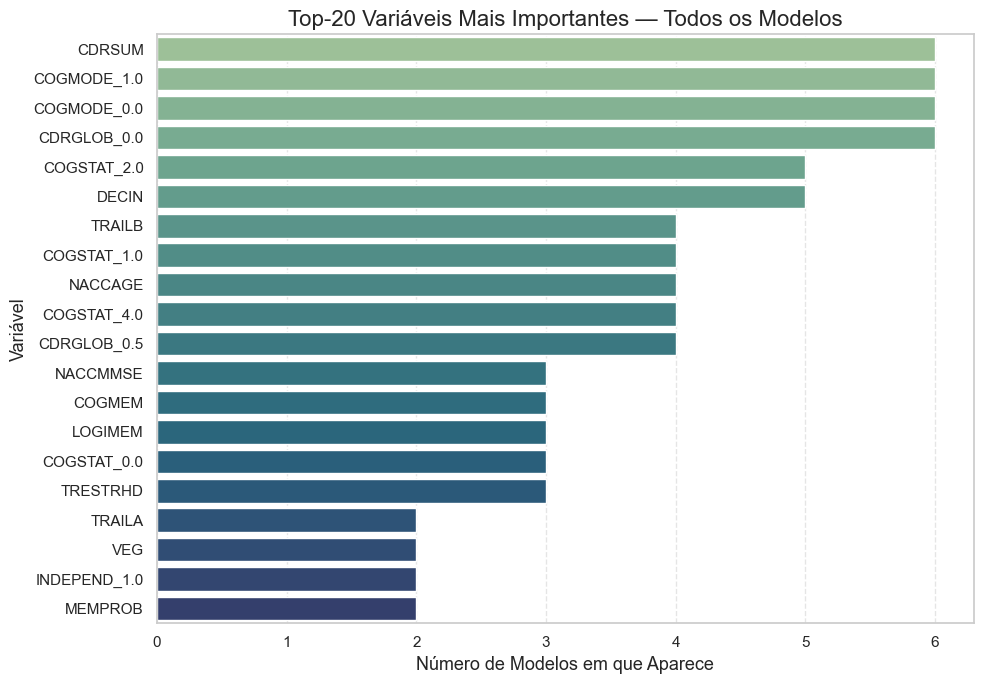


Figura salva como: 5fold/top20_features_geral.png


In [41]:

def get_top_k(feat_list, variable_names, k=20):
    feat_array = np.array(feat_list)

    if feat_array.ndim == 1:  
        feat_array = feat_array.reshape(1, -1)

    imp_mean = np.mean(np.abs(feat_array), axis=0)

    idx_sorted = np.argsort(-imp_mean)

    return [variable_names[i] for i in idx_sorted[:k]]


model_names = ["LR", "SVM", "RF", "GB", "BNB", "MLP"]

top20_dict = {}

for m in model_names:
    feat_list = model_results[m]["feat"]
    vars_ = model_results[m]["variables"]
    
    top20_dict[m] = get_top_k(feat_list, vars_, k=20)


all_features = sum(top20_dict.values(), [])

freq_df = (
    pd.Series(all_features)
    .value_counts()
    .reset_index()
)
freq_df.columns = ["Variável", "Frequência"]

freq_top20 = freq_df.head(20)

print("Top-20 variáveis mais recorrentes entre todos os modelos:")
display(freq_top20)


plt.figure(figsize=(10, 7))
sns.barplot(
    data=freq_top20,
    x="Frequência",
    y="Variável",
    palette="crest"
)

plt.title("Top-20 Variáveis Mais Importantes — Todos os Modelos", fontsize=16)
plt.xlabel("Número de Modelos em que Aparece", fontsize=13)
plt.ylabel("Variável", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("top20_features_geral.png", dpi=300)
plt.show()

print("\nFigura salva como: 5fold/top20_features_geral.png")


In [ ]:
def build_importance_matrix(model_results, model_names):
    all_vars = model_results["LR"]["variables"]
    mat = pd.DataFrame(index=all_vars)

    for m in model_names:
        feat_list = np.array(model_results[m]["feat"])
        if feat_list.ndim == 1:
            feat_list = feat_list.reshape(1, -1)

        imp_mean = np.mean(np.abs(feat_list), axis=0)
        imp_norm = imp_mean / (imp_mean.max() + 1e-9)

        mat[m] = imp_norm

    return mat


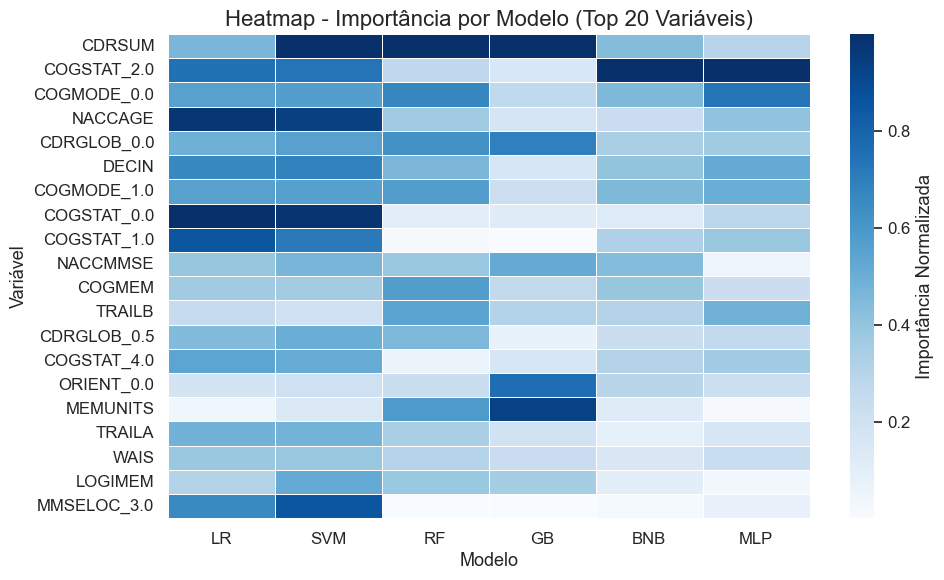

In [97]:
models = ["LR", "SVM", "RF", "GB", "BNB", "MLP"]

importance_matrix = build_importance_matrix(model_results, models)

top_vars = importance_matrix.mean(axis=1).sort_values(ascending=False).head(20)
imp20 = importance_matrix.loc[top_vars.index]

sns.set(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(10, 6))
sns.heatmap(
    imp20,
    cmap="Blues",          
    linewidths=0.4,
    linecolor="white",
    cbar_kws={'label': 'Importância Normalizada'}
)

plt.title("Heatmap - Importância por Modelo (Top 20 Variáveis)", fontsize=16)
plt.xlabel("Modelo", fontsize=13)
plt.ylabel("Variável", fontsize=13)
plt.tight_layout()
plt.show()

